# Bed Moves MDP

An ICU ward is set up as so: It has three beds in isolation units, and 14 standard beds split accross a corridor.

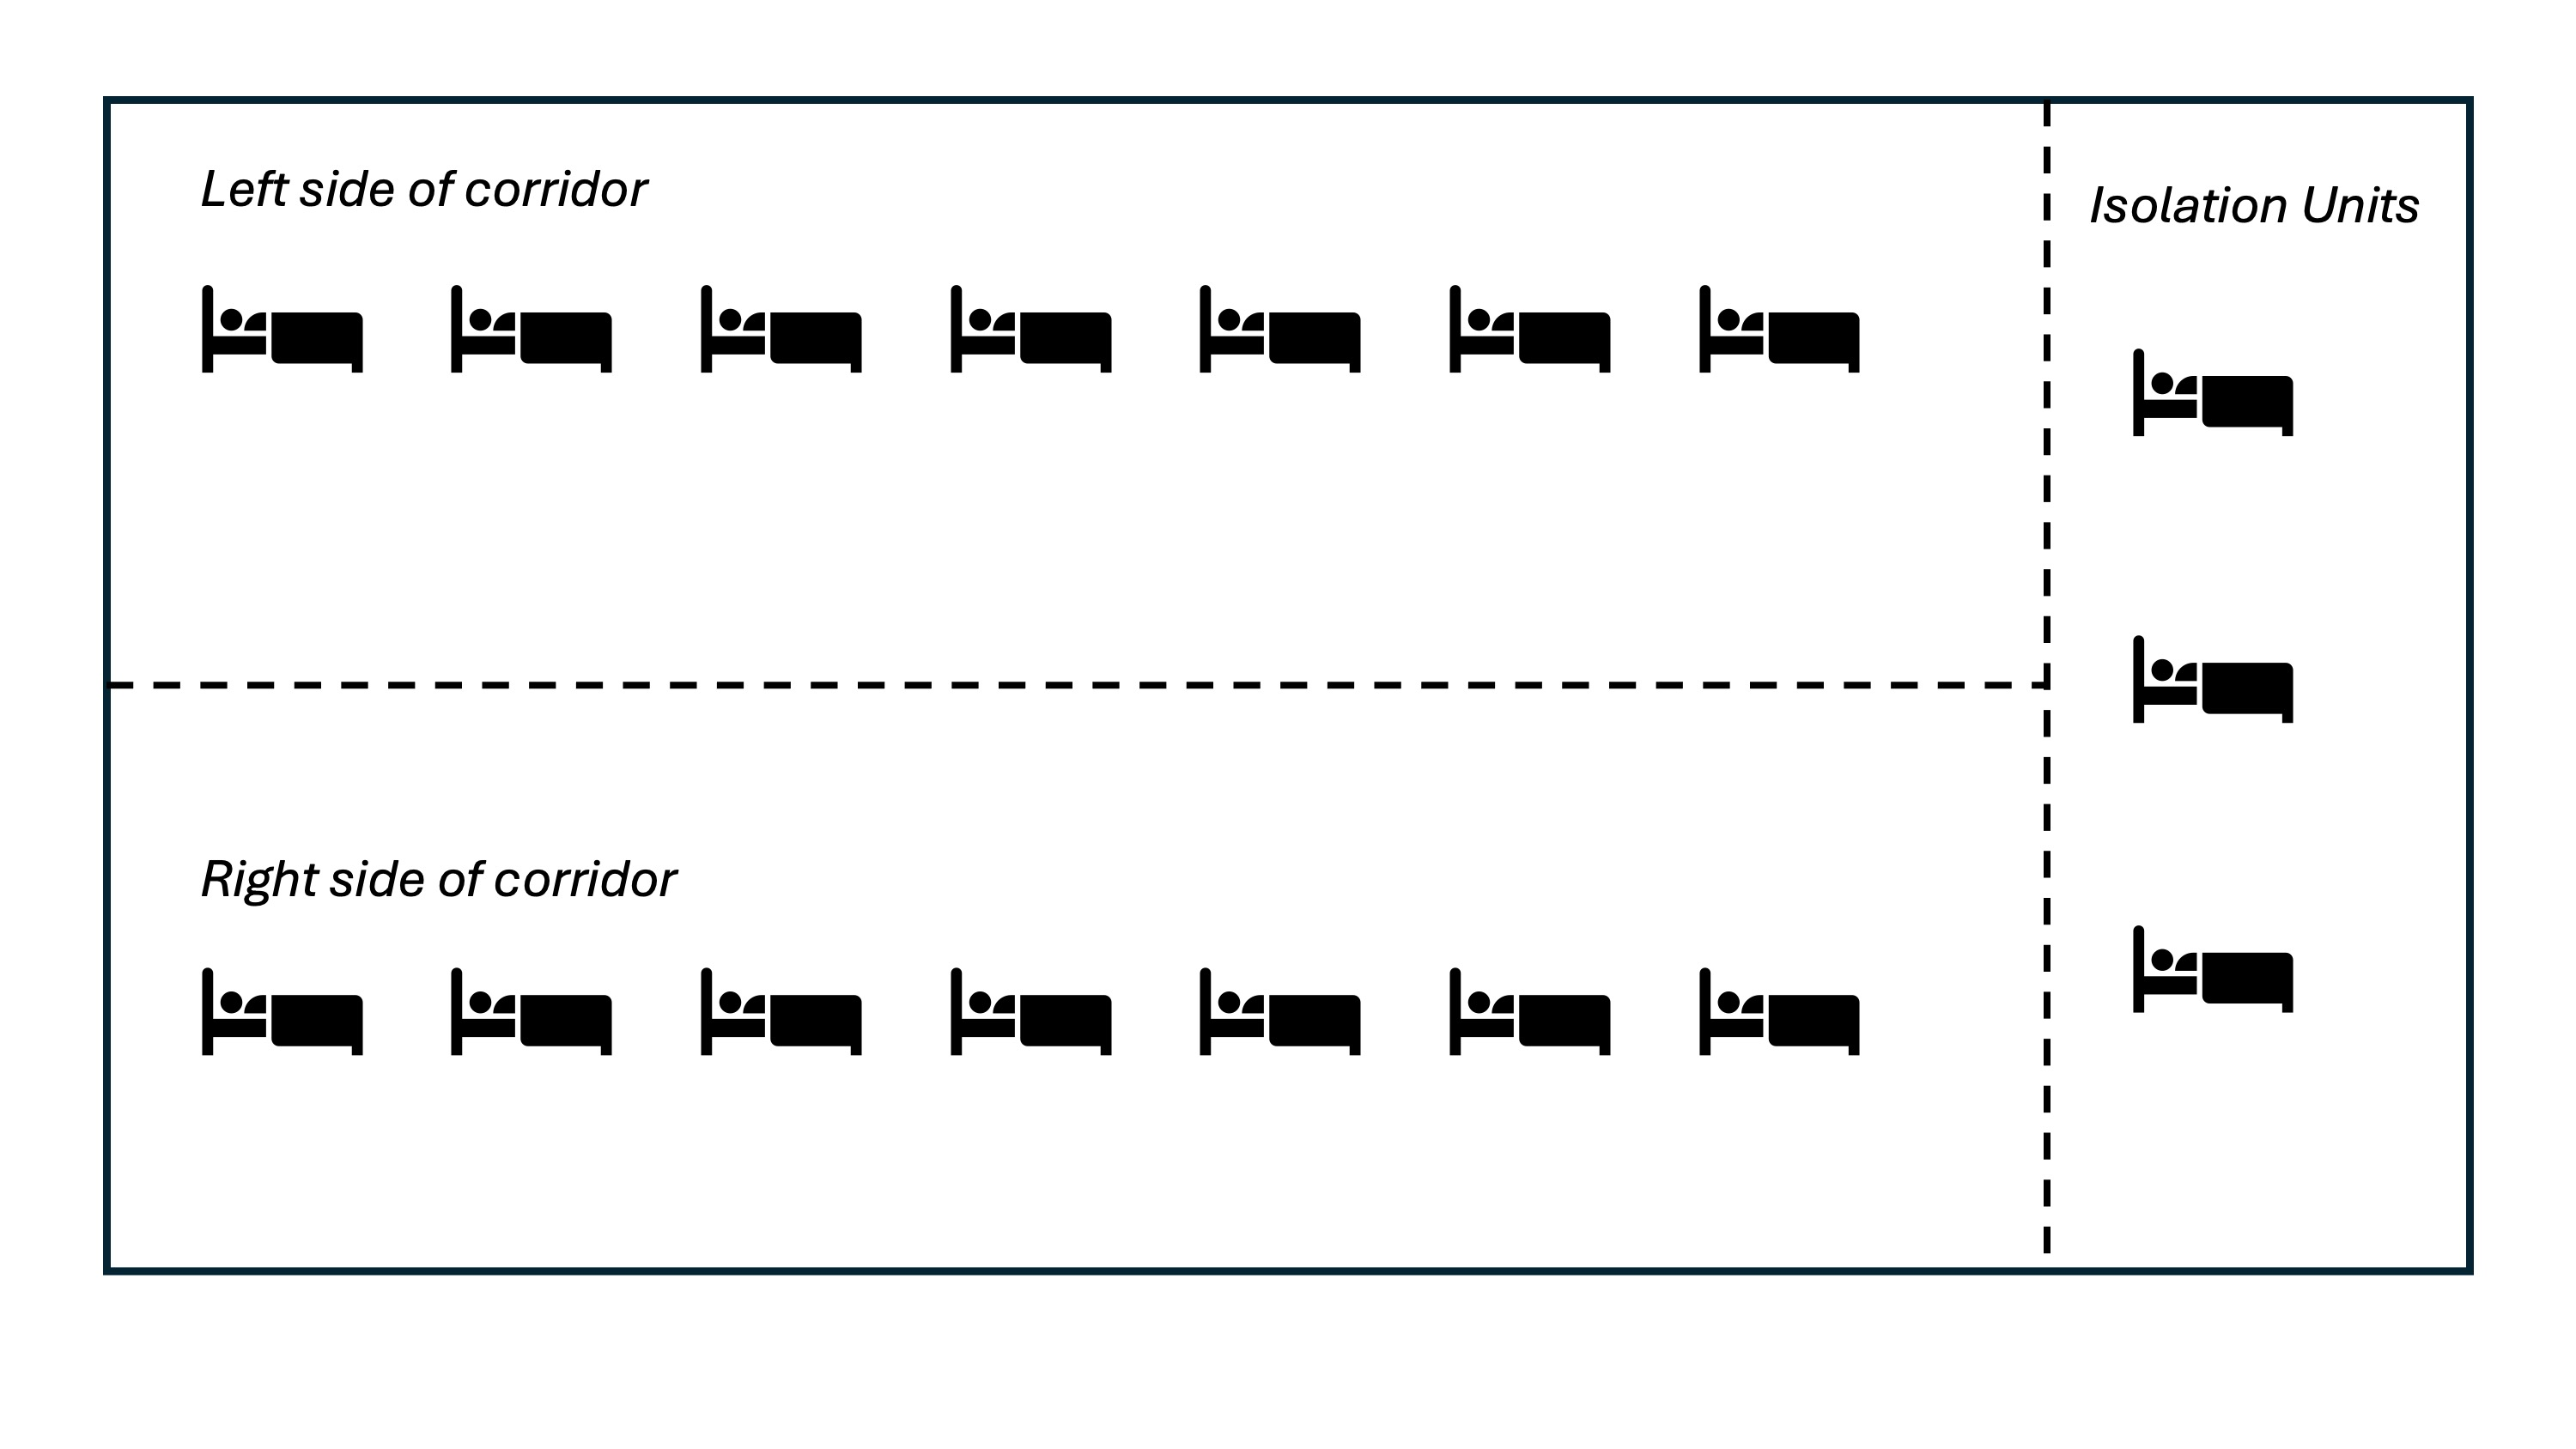

The beds can be split into 9 blocks, where each block can normally be looked after by 1 FTE. Each isolation bed is treated as one block (a 1 to 1 ratio), other beds are either in blocks of 2 beds (a 1 to 2 ratio when full), or in blocks of 3 (a 1 to 3 ratio when full). The blocks are labelled as follows:

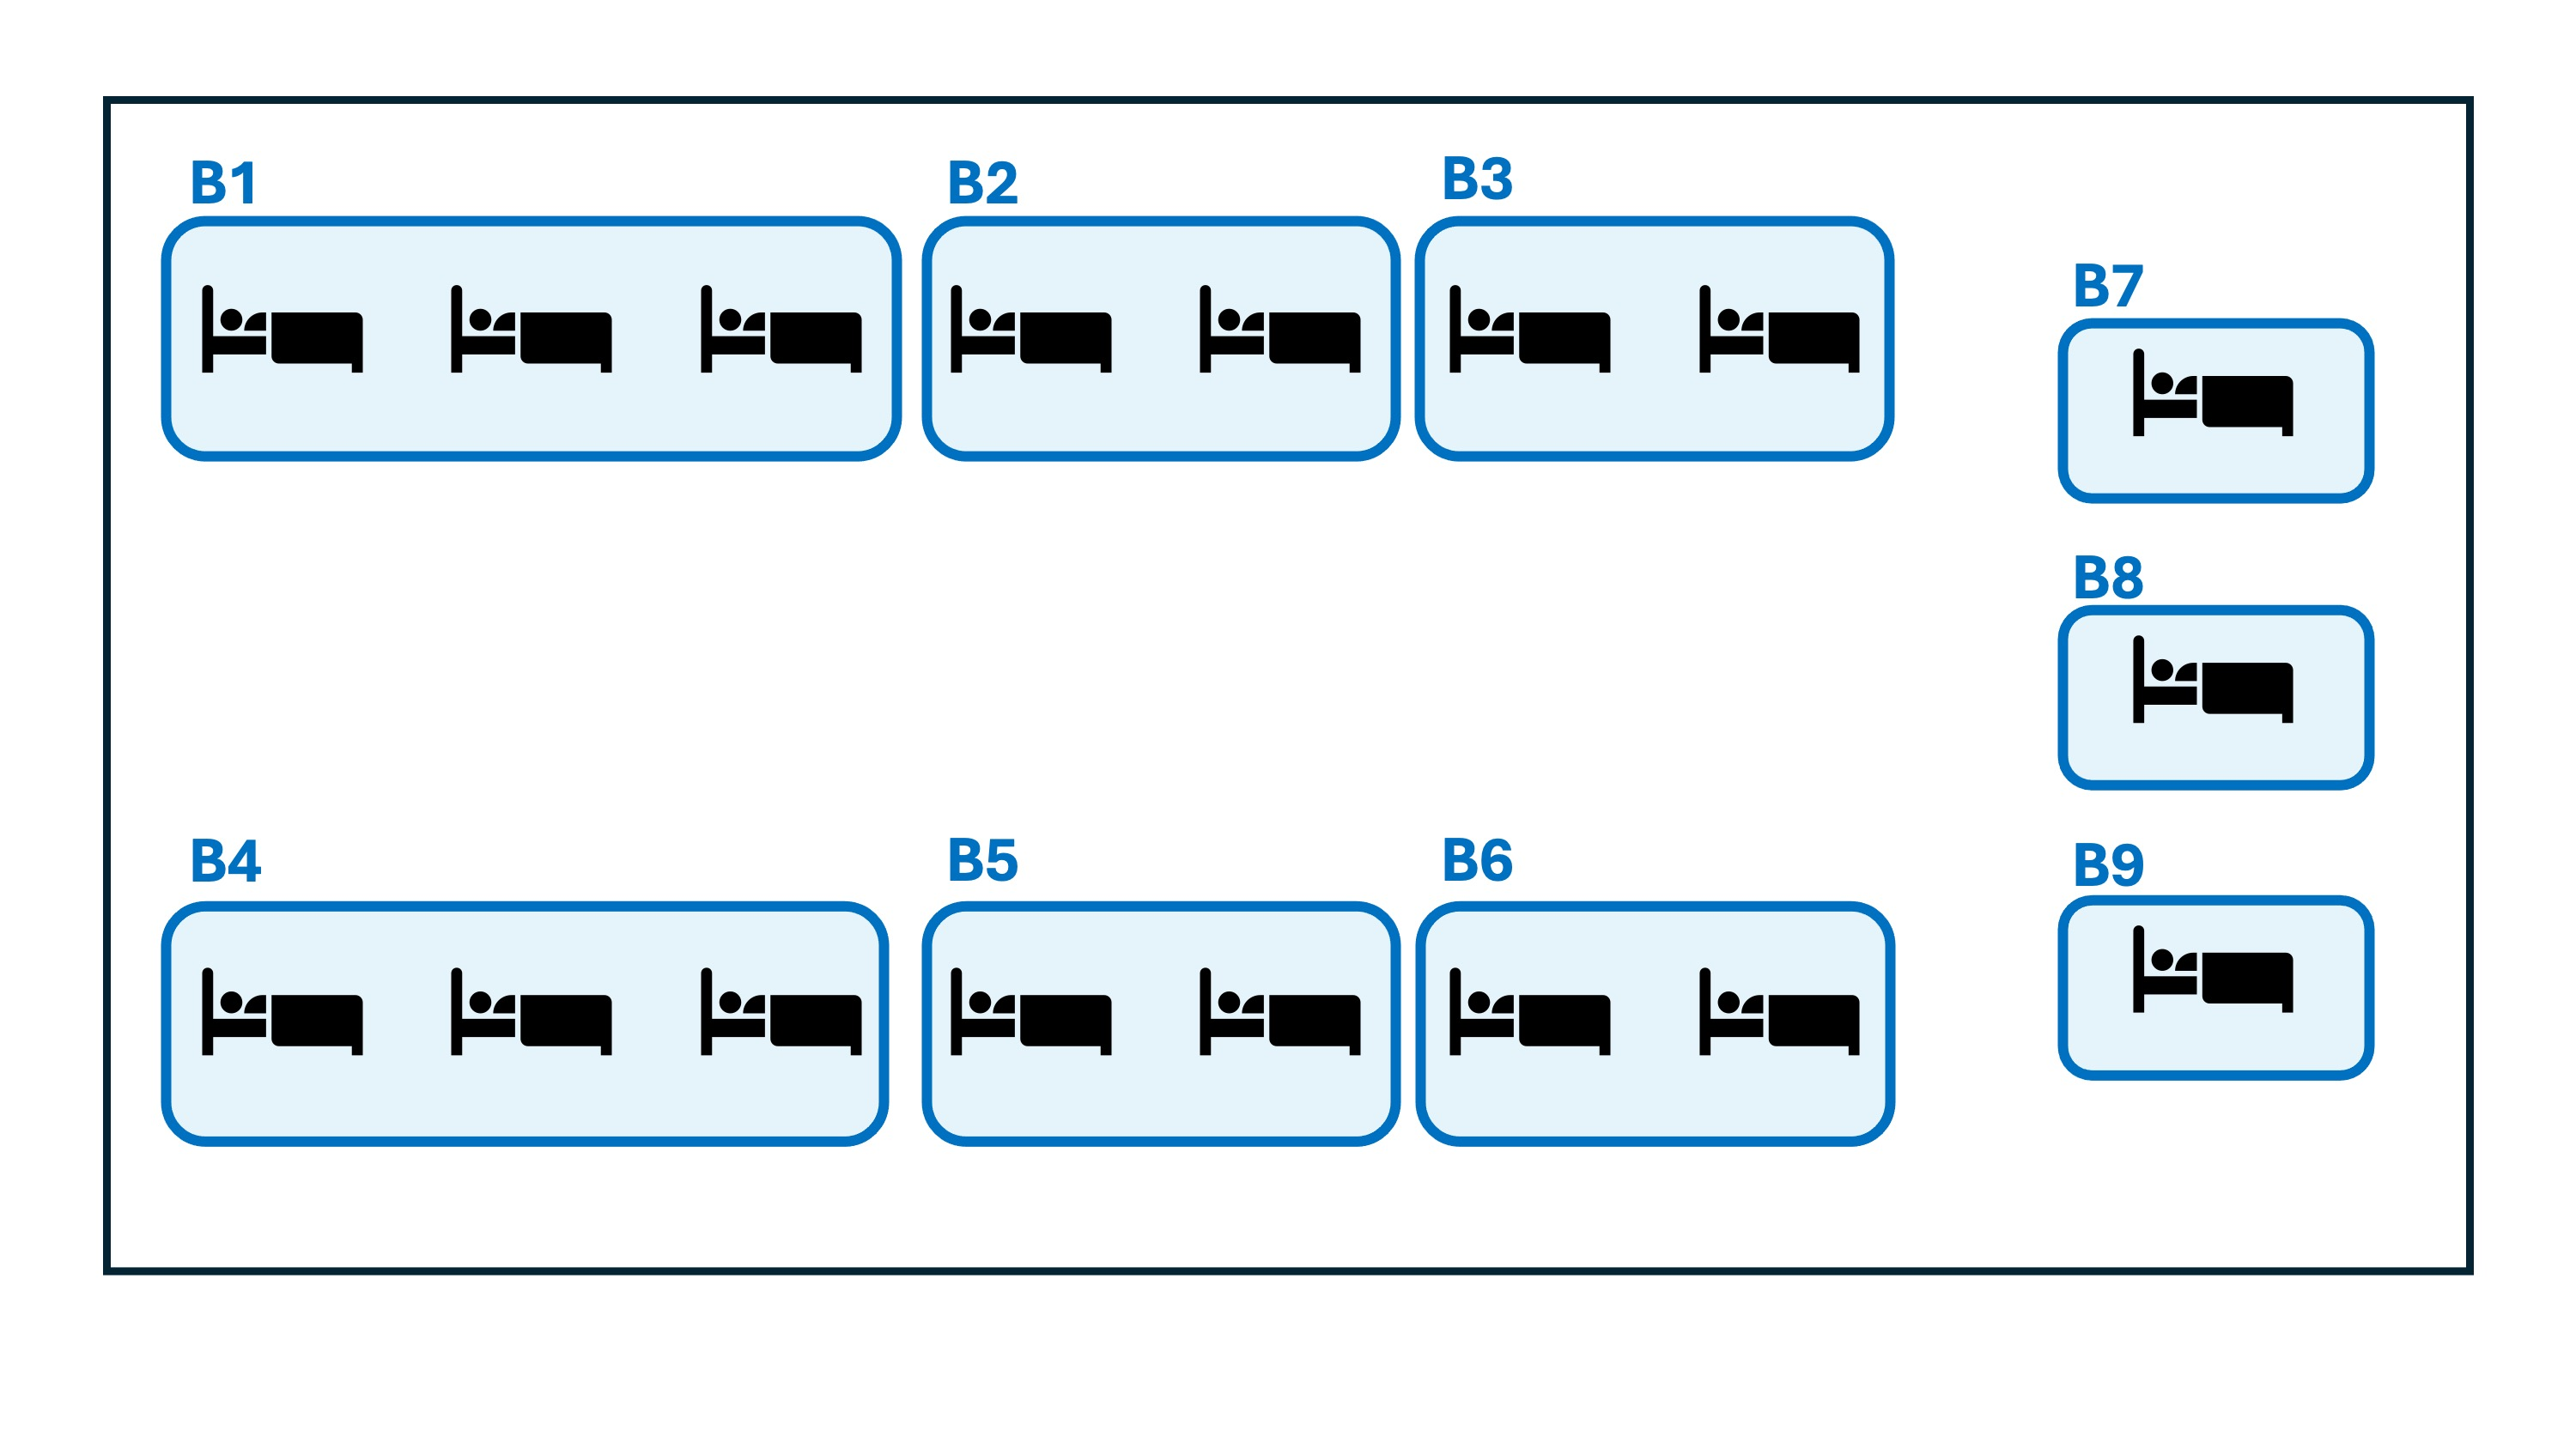

Numbering the blocks 1 through nine, each block has a capacity depending on the number of beds:

In [2]:
max_capacities = (3, 2, 2, 3, 2, 2, 1, 1, 1)

We consider three different types of patient:
+ green patients who can be treated on a 1-2 or 1-3 resource ratio;
+ amber patients who must be treated on a 1-1 resource ratio;
+ red patients who must be treated on a 1-1 resource ratio, and also be placed in an isolation unit.

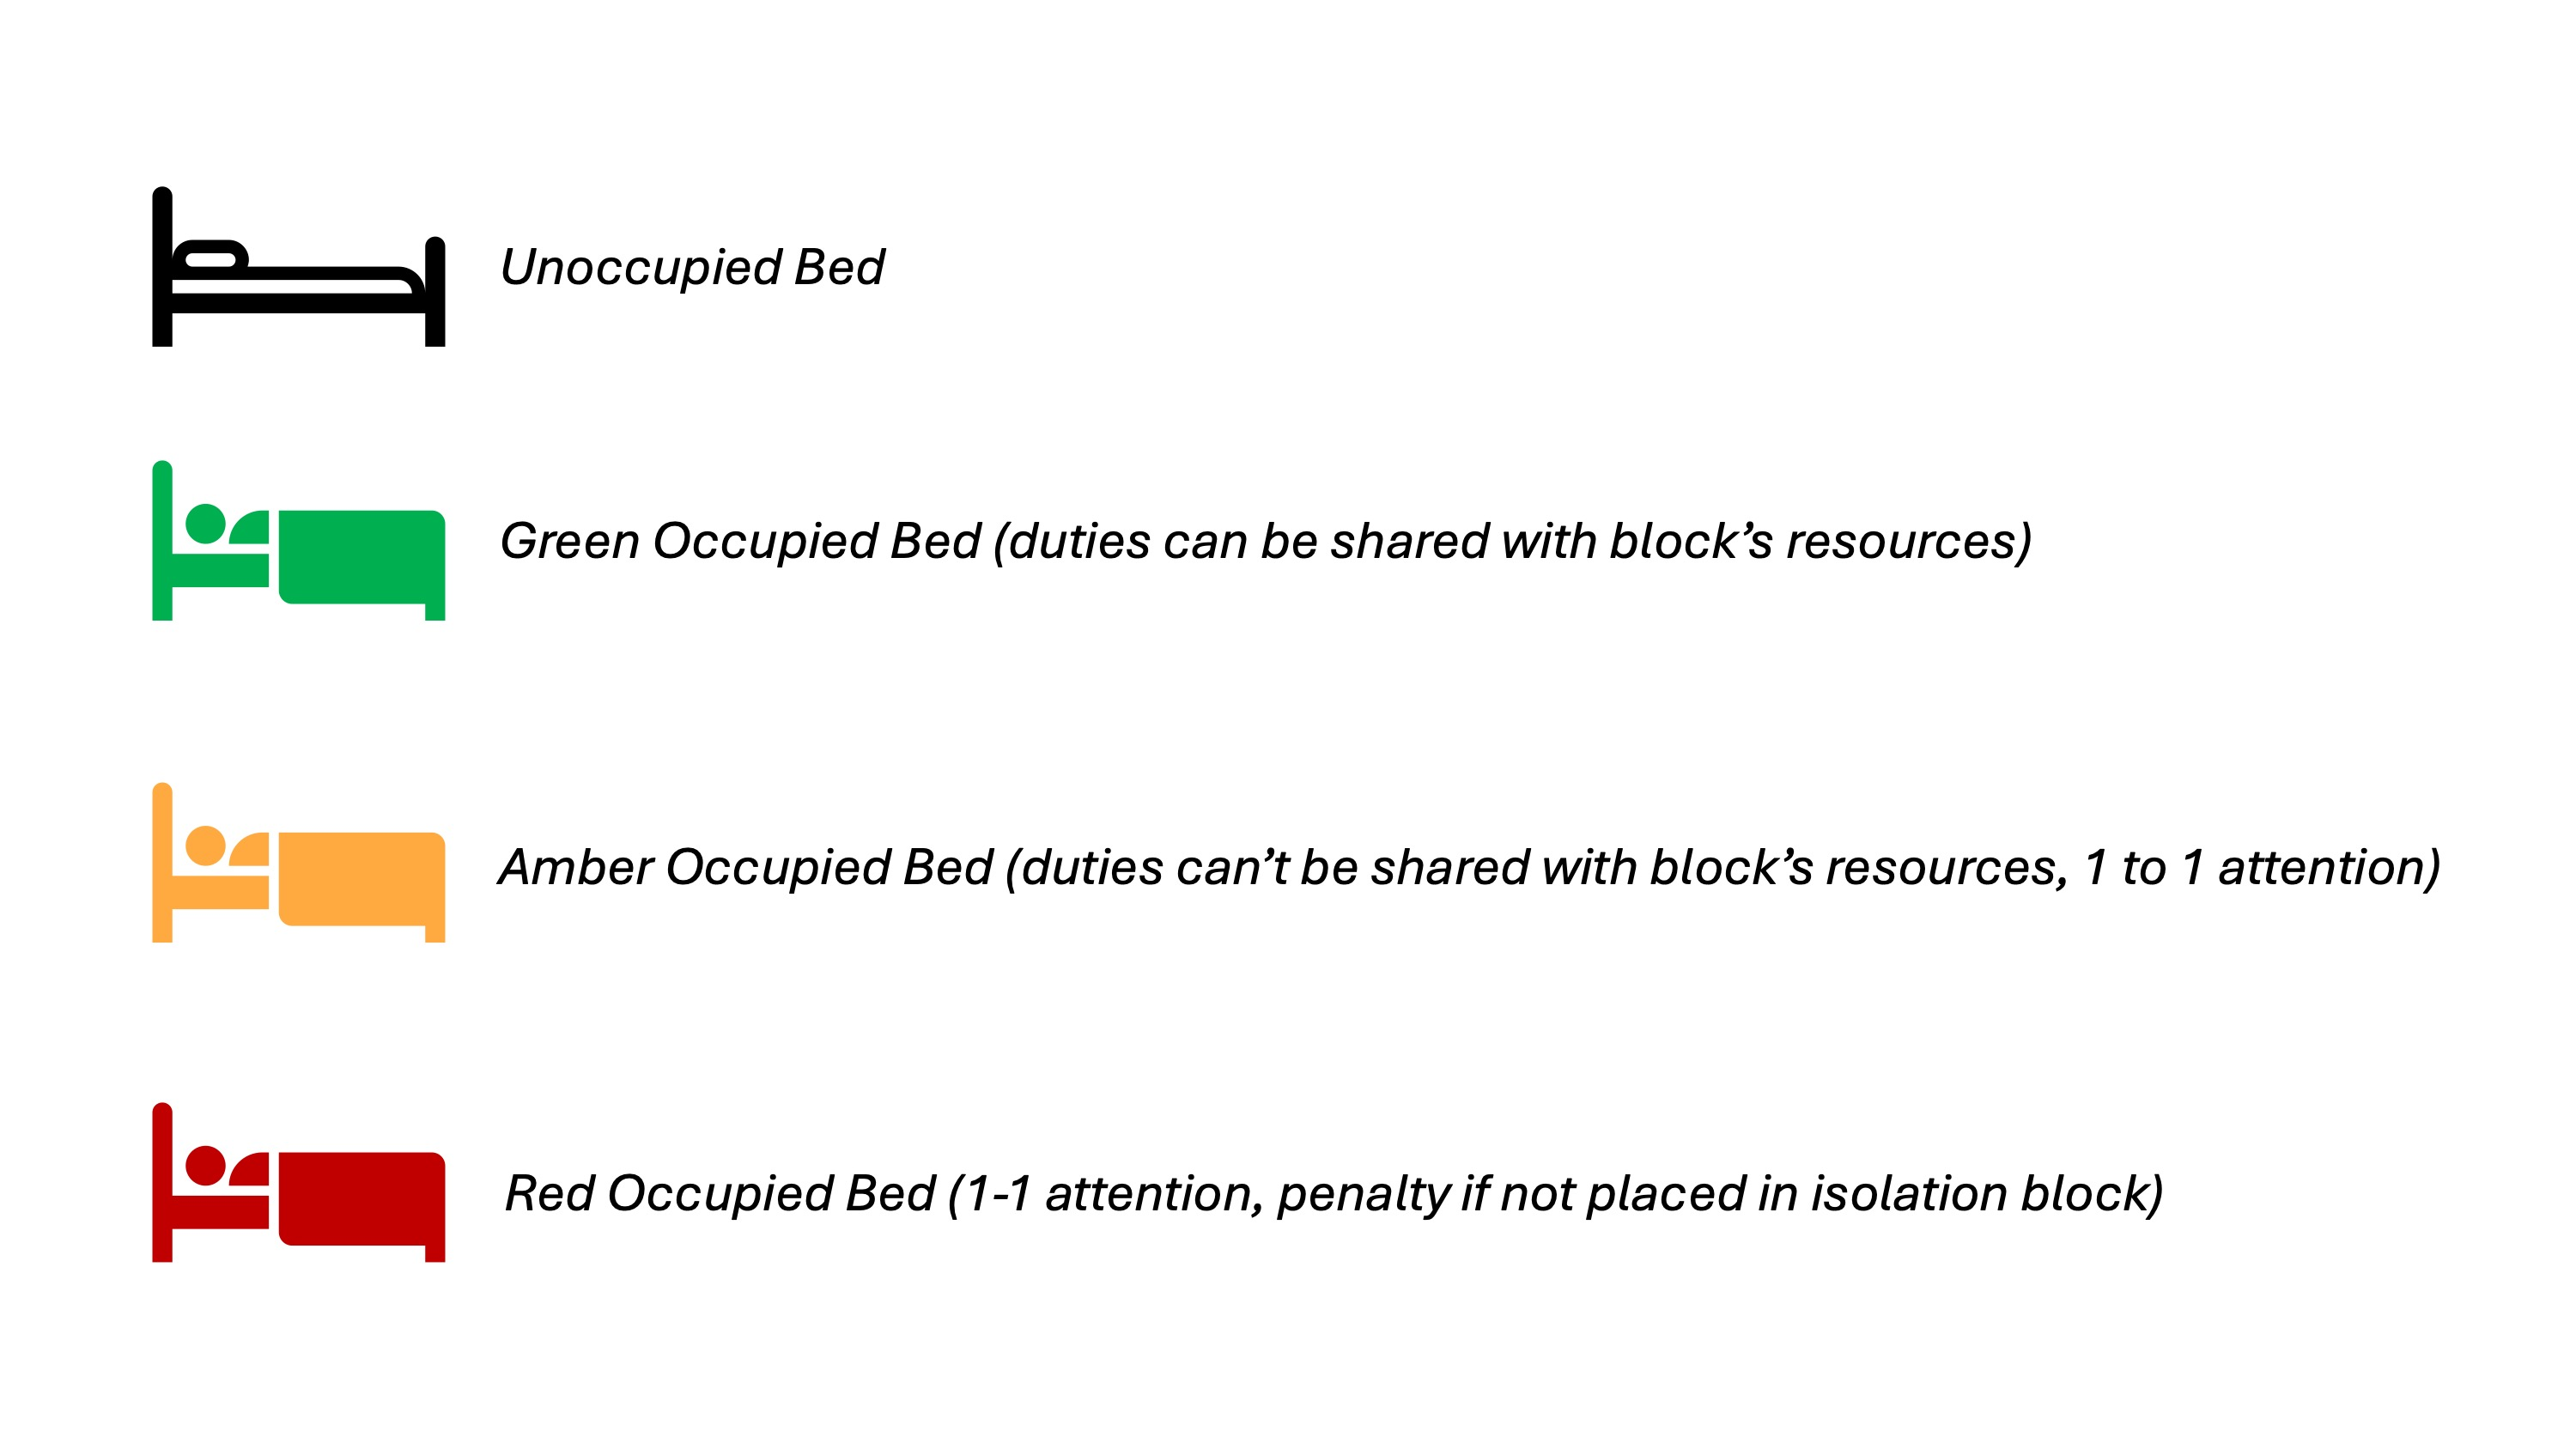

A ward's state can be described by a $9 \times 3$ matrix, representing the numbers of each of the 3 patient types in each of the 9 blocks. An example is given:

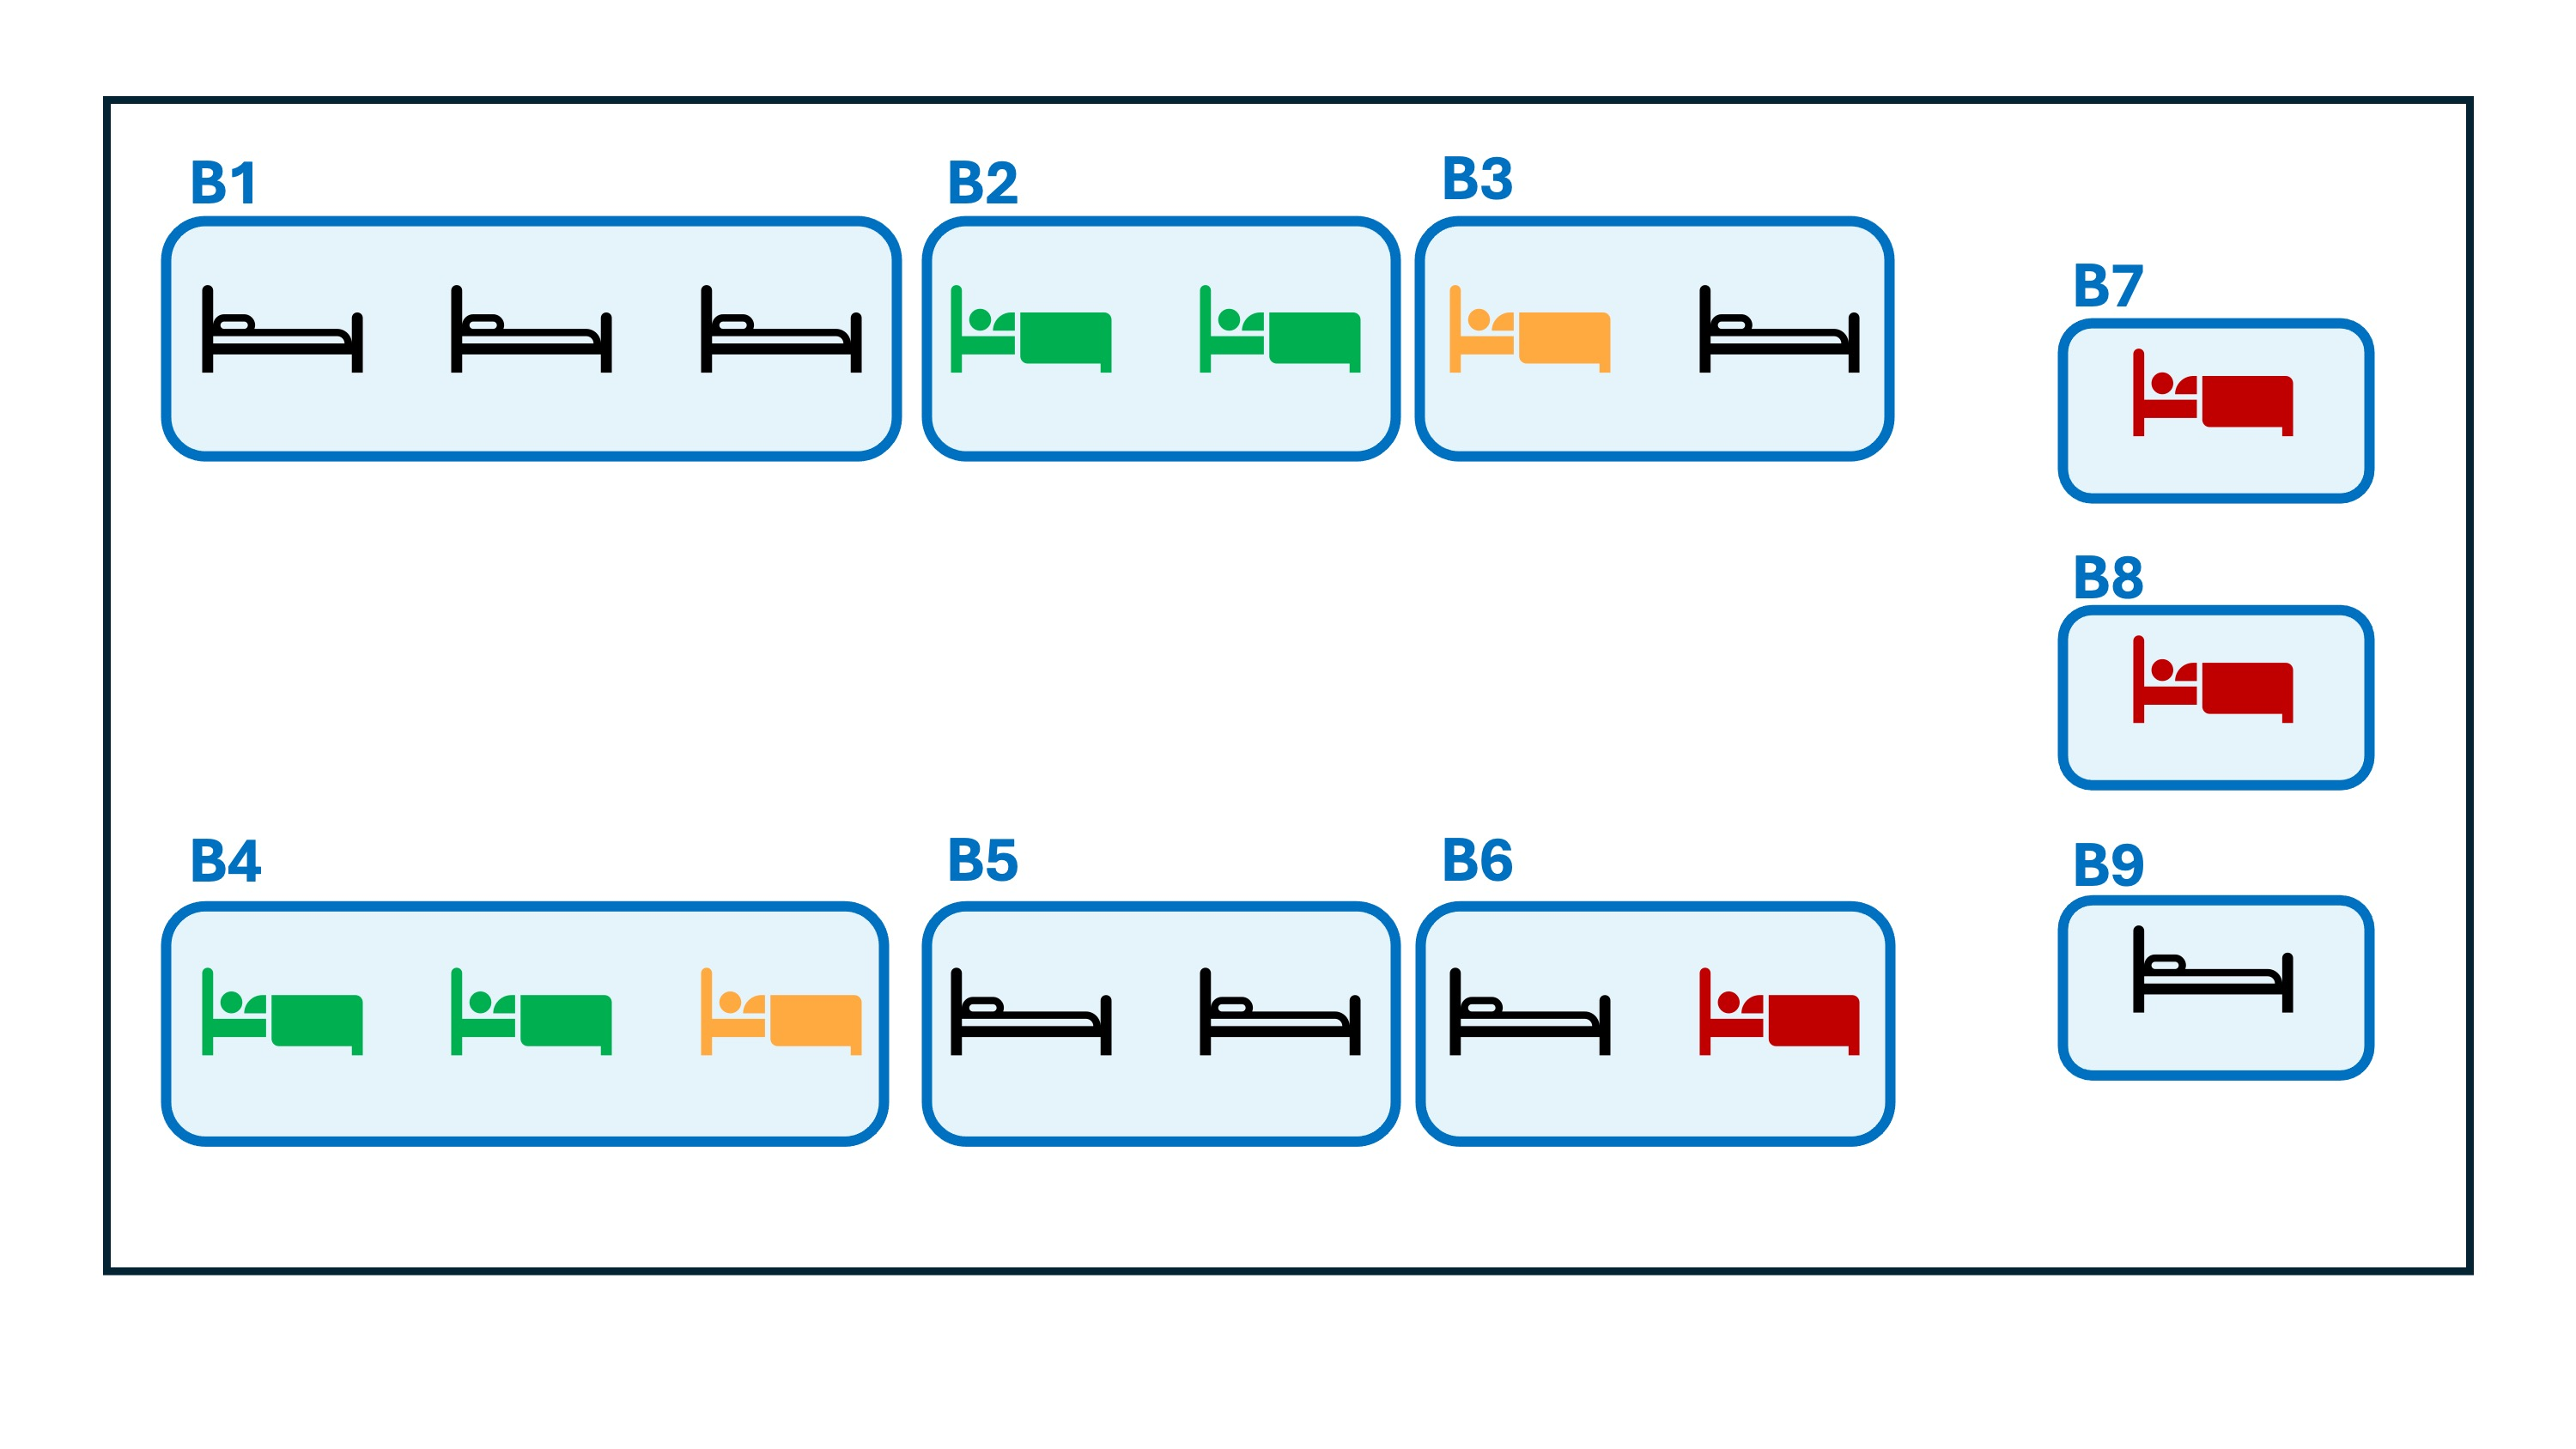

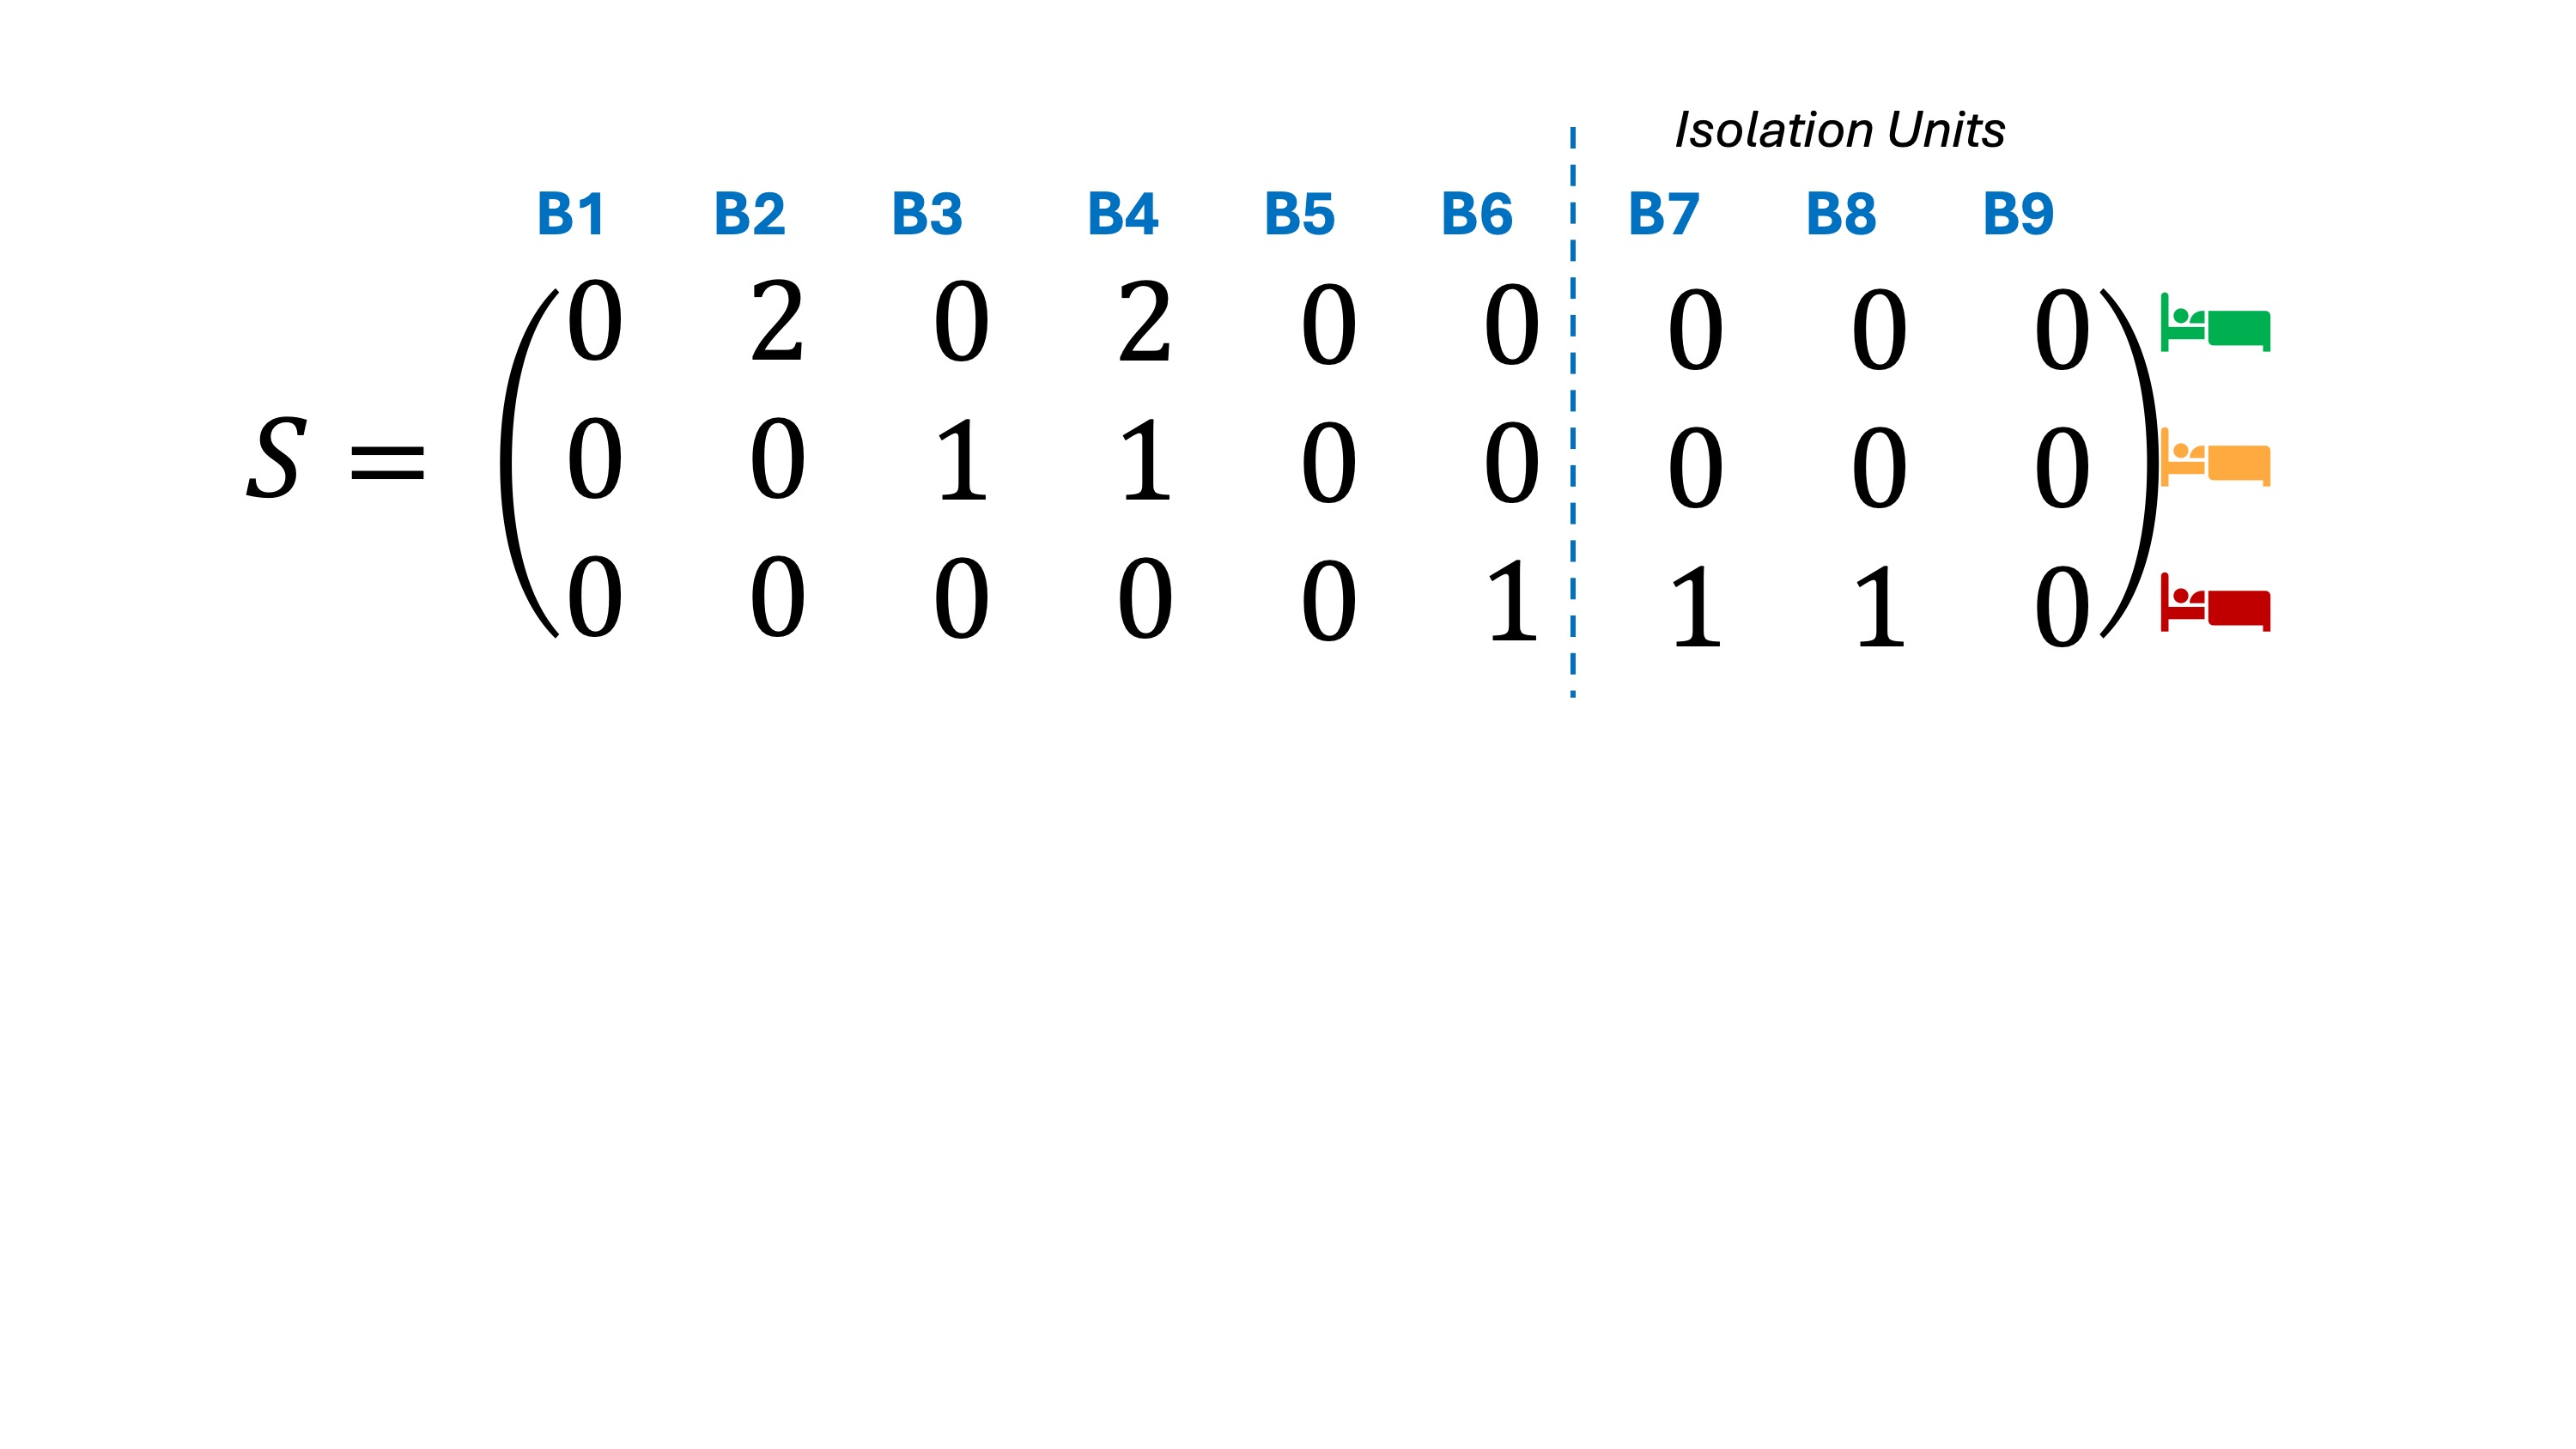

In [3]:
import itertools
possible_states = list(itertools.product(itertools.product(*[range(c) for c in max_capacities]), repeat=3))

In [4]:
def check_is_possible(state):
    for b in range(9):
        if state[0][b] + state[1][b] + state[2][b] > max_capacities[b]:
            return False
    return True

In [5]:
import tqdm.notebook as tqdm
import numpy as np
states = []
for s in tqdm.tqdm(possible_states):
    if check_is_possible(s):
        states.append(np.matrix(s))

  0%|          | 0/2985984 [00:00<?, ?it/s]

In [6]:
len(states)

693889

Therefore there are $693,889$ possible states, including those incuring penalties.

### Rewards, Costs, and Resource Use

Resource use can be calculated from observing the state:
 + Each block will require 1 resource if at least one bed is occupied,
 + Each amber or red patient required an additional resource if they are not in a block alone.

A penalty of $\alpha$ will also be incurred for each red patient not placed in an isolation ward.

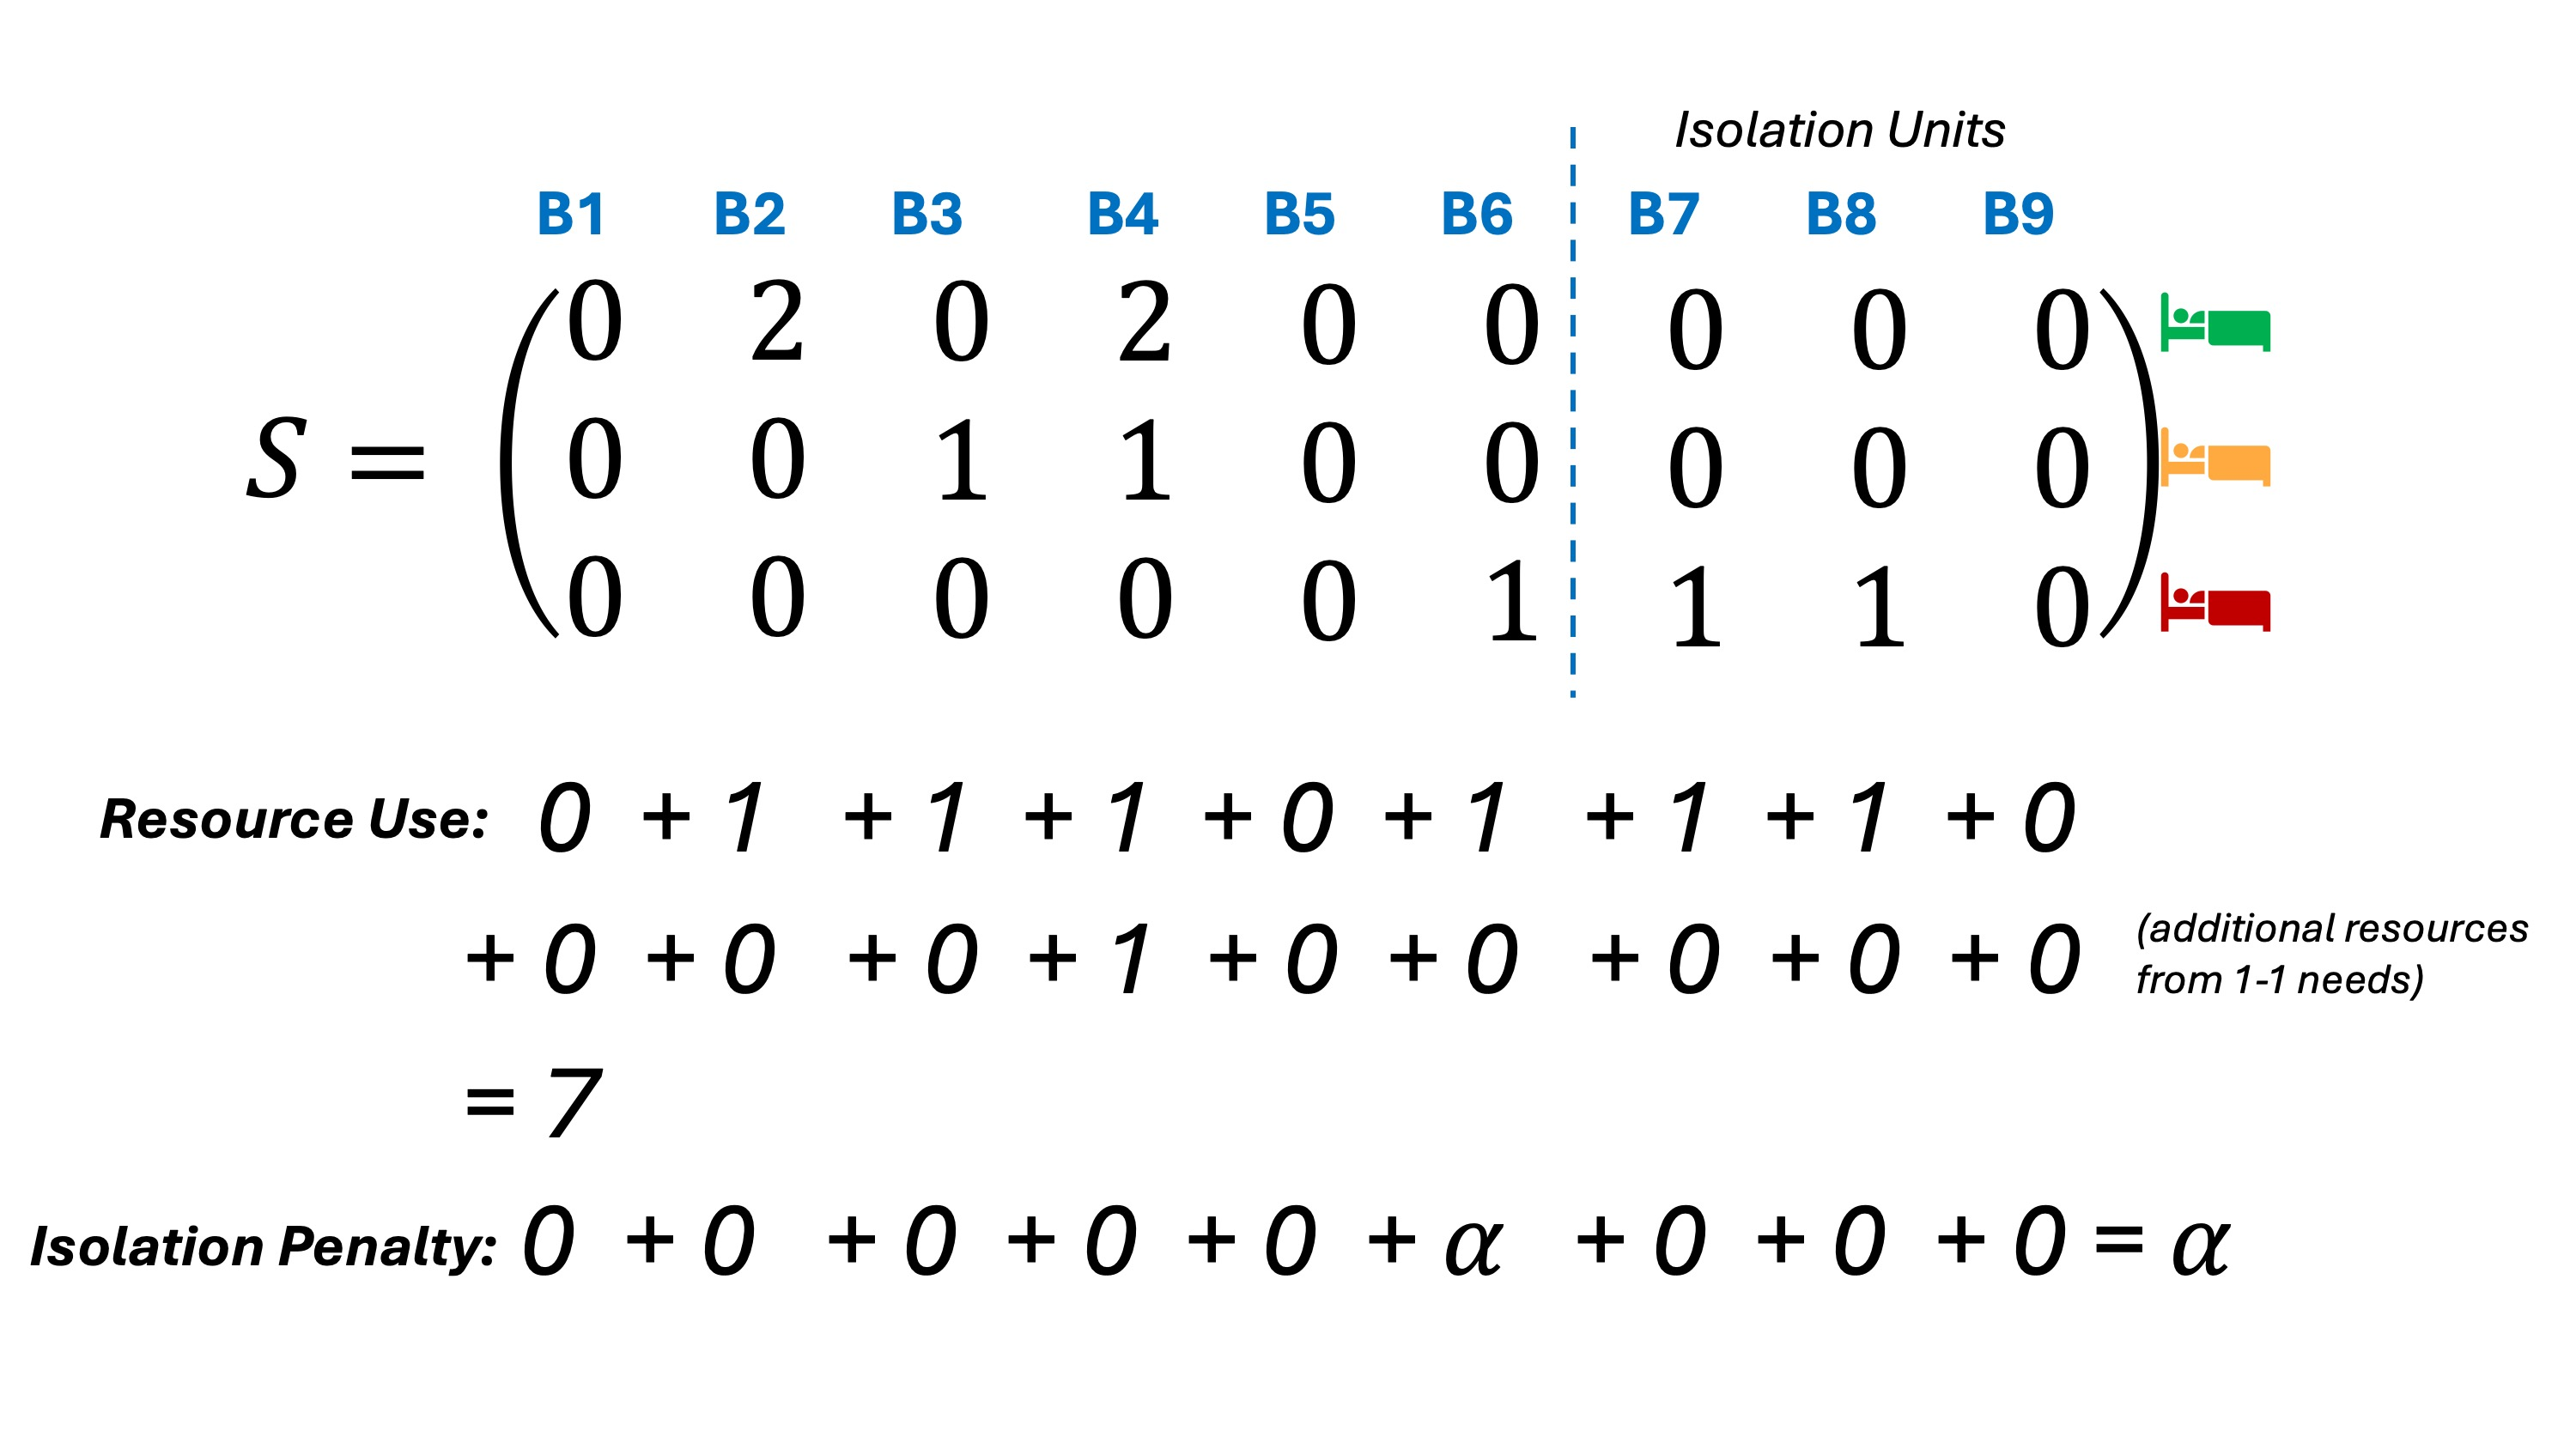

In [7]:
def get_resource_use(state):
    """
    Calculates the resource use for a given state
    """
    green = (state[0,:] > 0).sum()
    amber = state[1,:].sum()
    red = state[2,:].sum()
    return green + amber + red

In [8]:
S = np.matrix(
    (
        (0, 2, 0, 2, 0, 0, 0, 0, 0),
        (0, 0, 1, 1, 0, 0, 0, 0, 0),
        (0, 0, 0, 0, 0, 1, 1, 1, 0)
    )
)
get_resource_use(S)

np.int64(7)

In [9]:
def get_penalty(state, alpha):
    """
    Calculates the penalty for having isolation patients in a general block
    """
    return state[2,:-3].sum() * alpha

In [10]:
get_penalty(S, 10)

np.int64(10)

### Transitions

The MDP can transition between states when 3 things happen:

+ An arrival
+ A departure
+ A bed move

Arrival example: a green patient arrives, and is put in block 2:

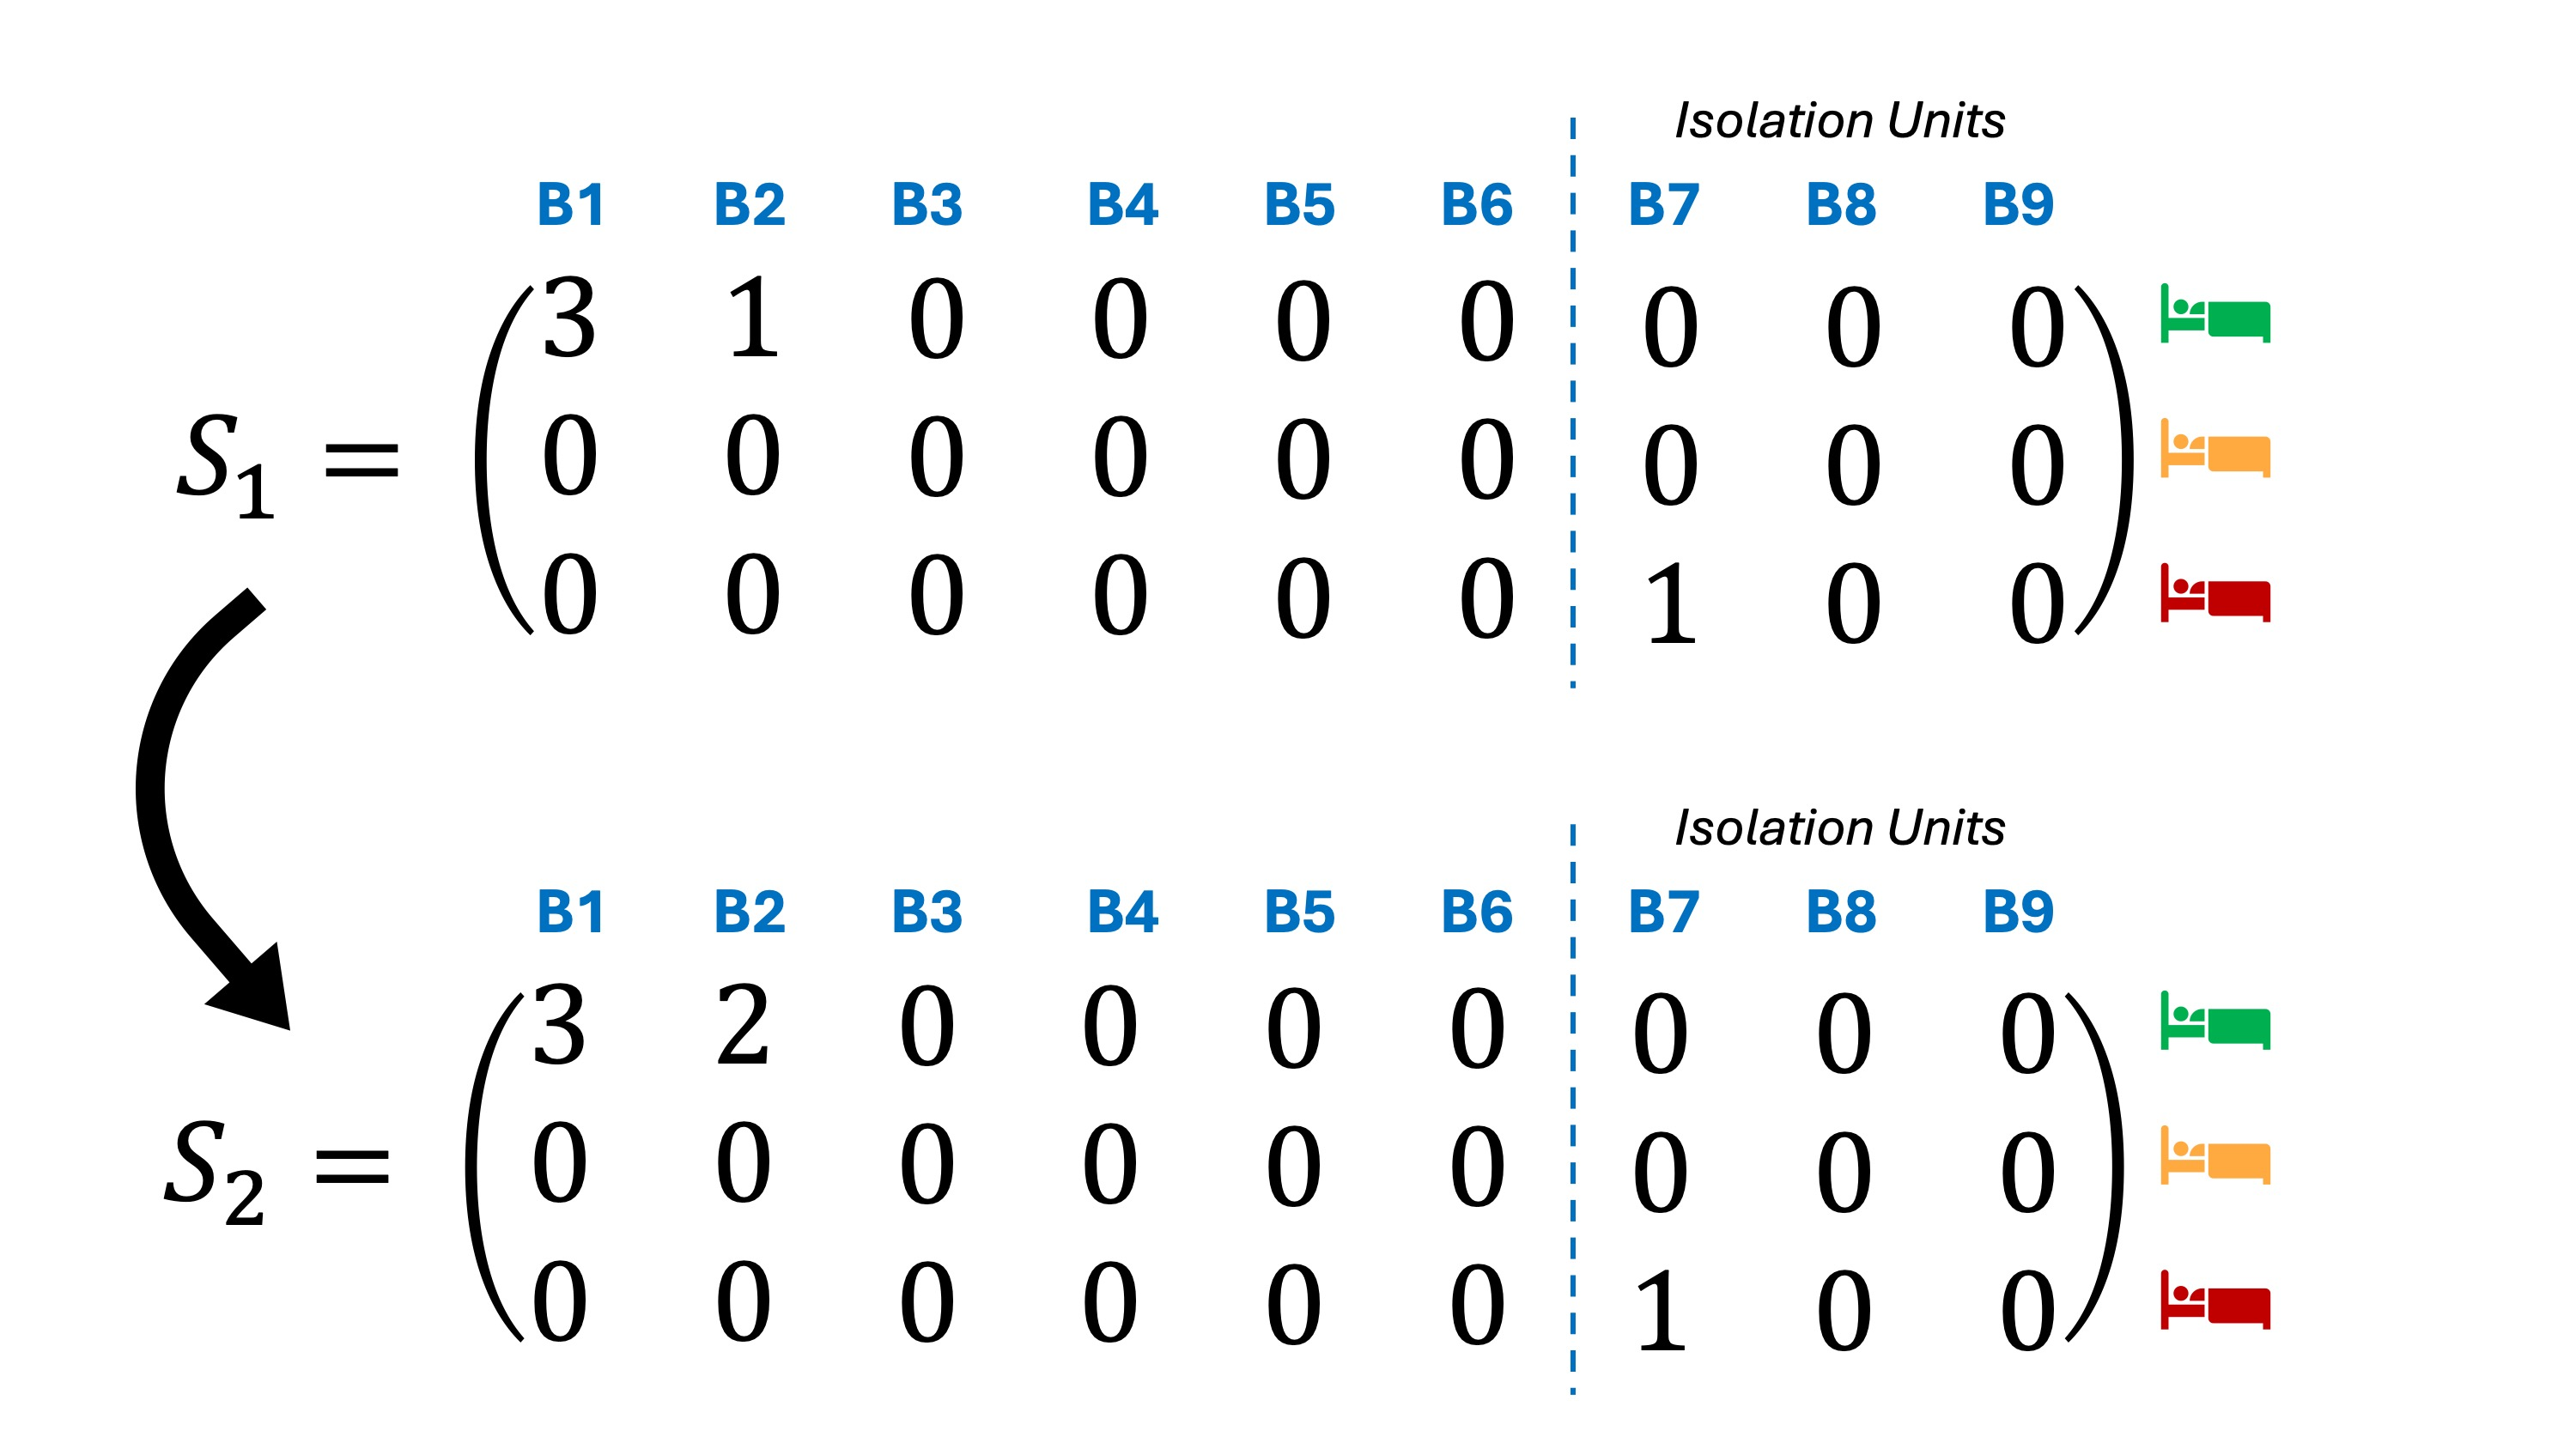

Departure example: A green patient from block B1 leaves:

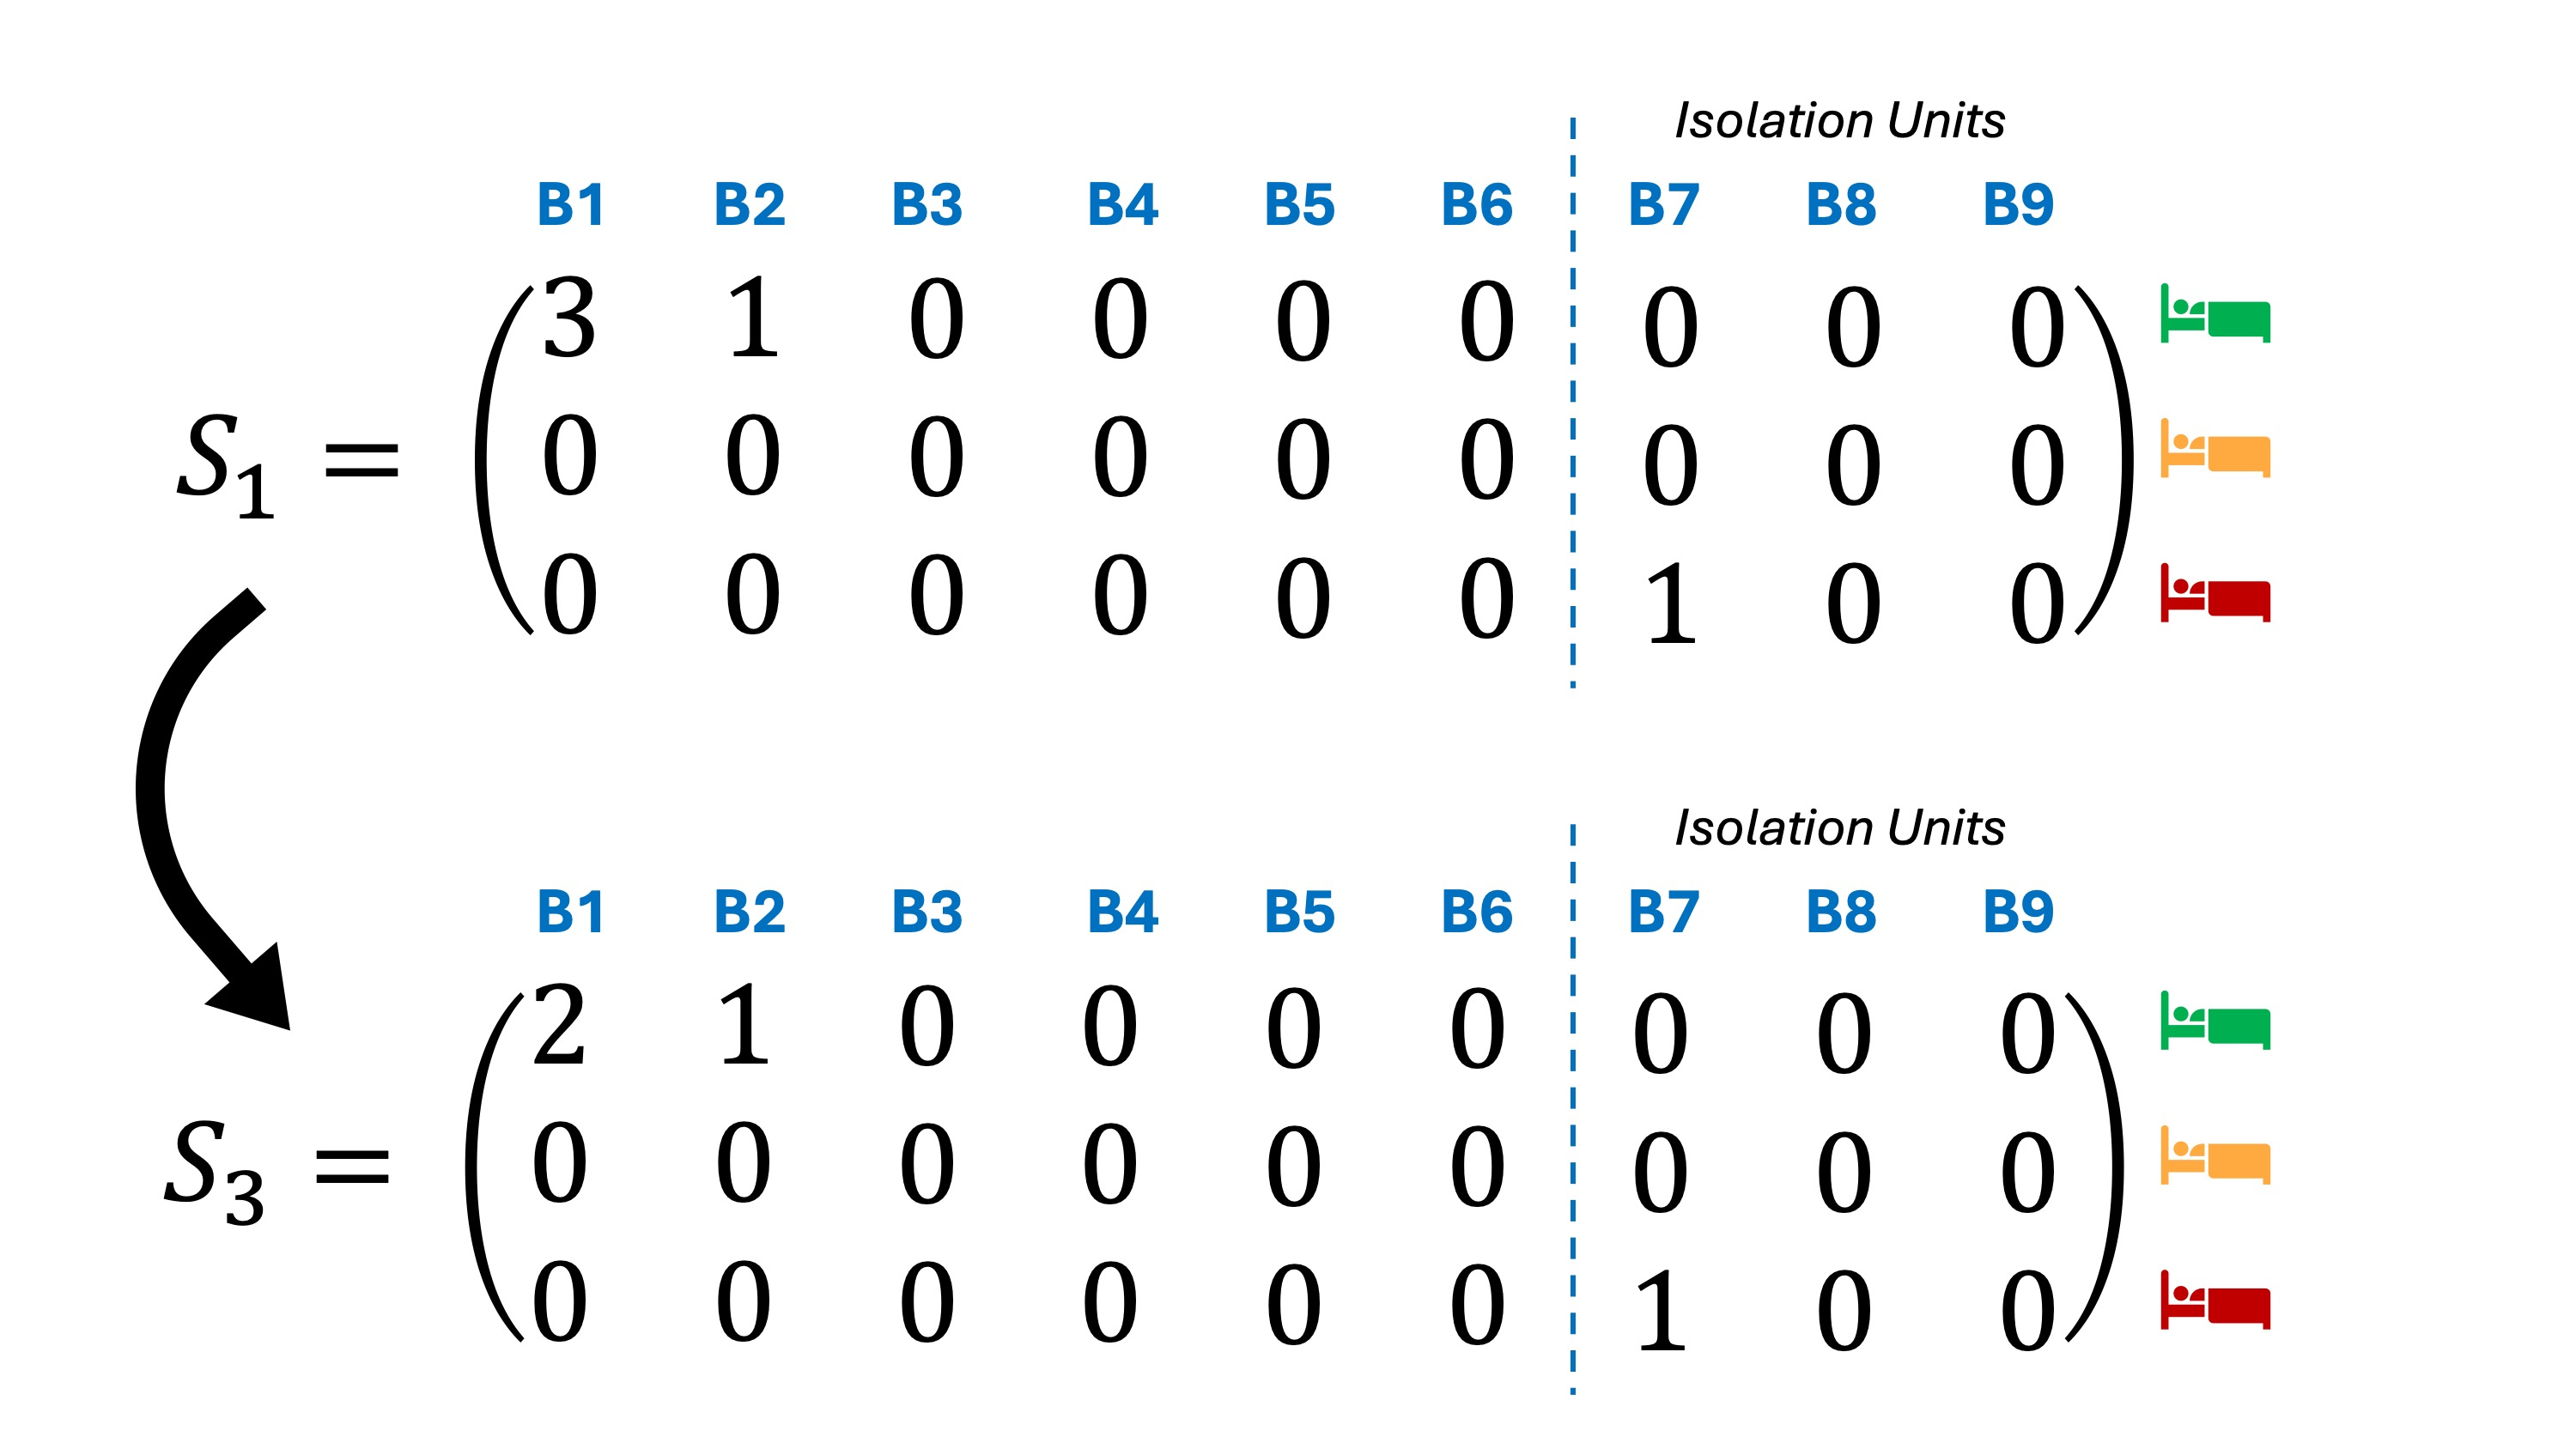

A bed move example: Moving one green patient from block B1 to block B3:

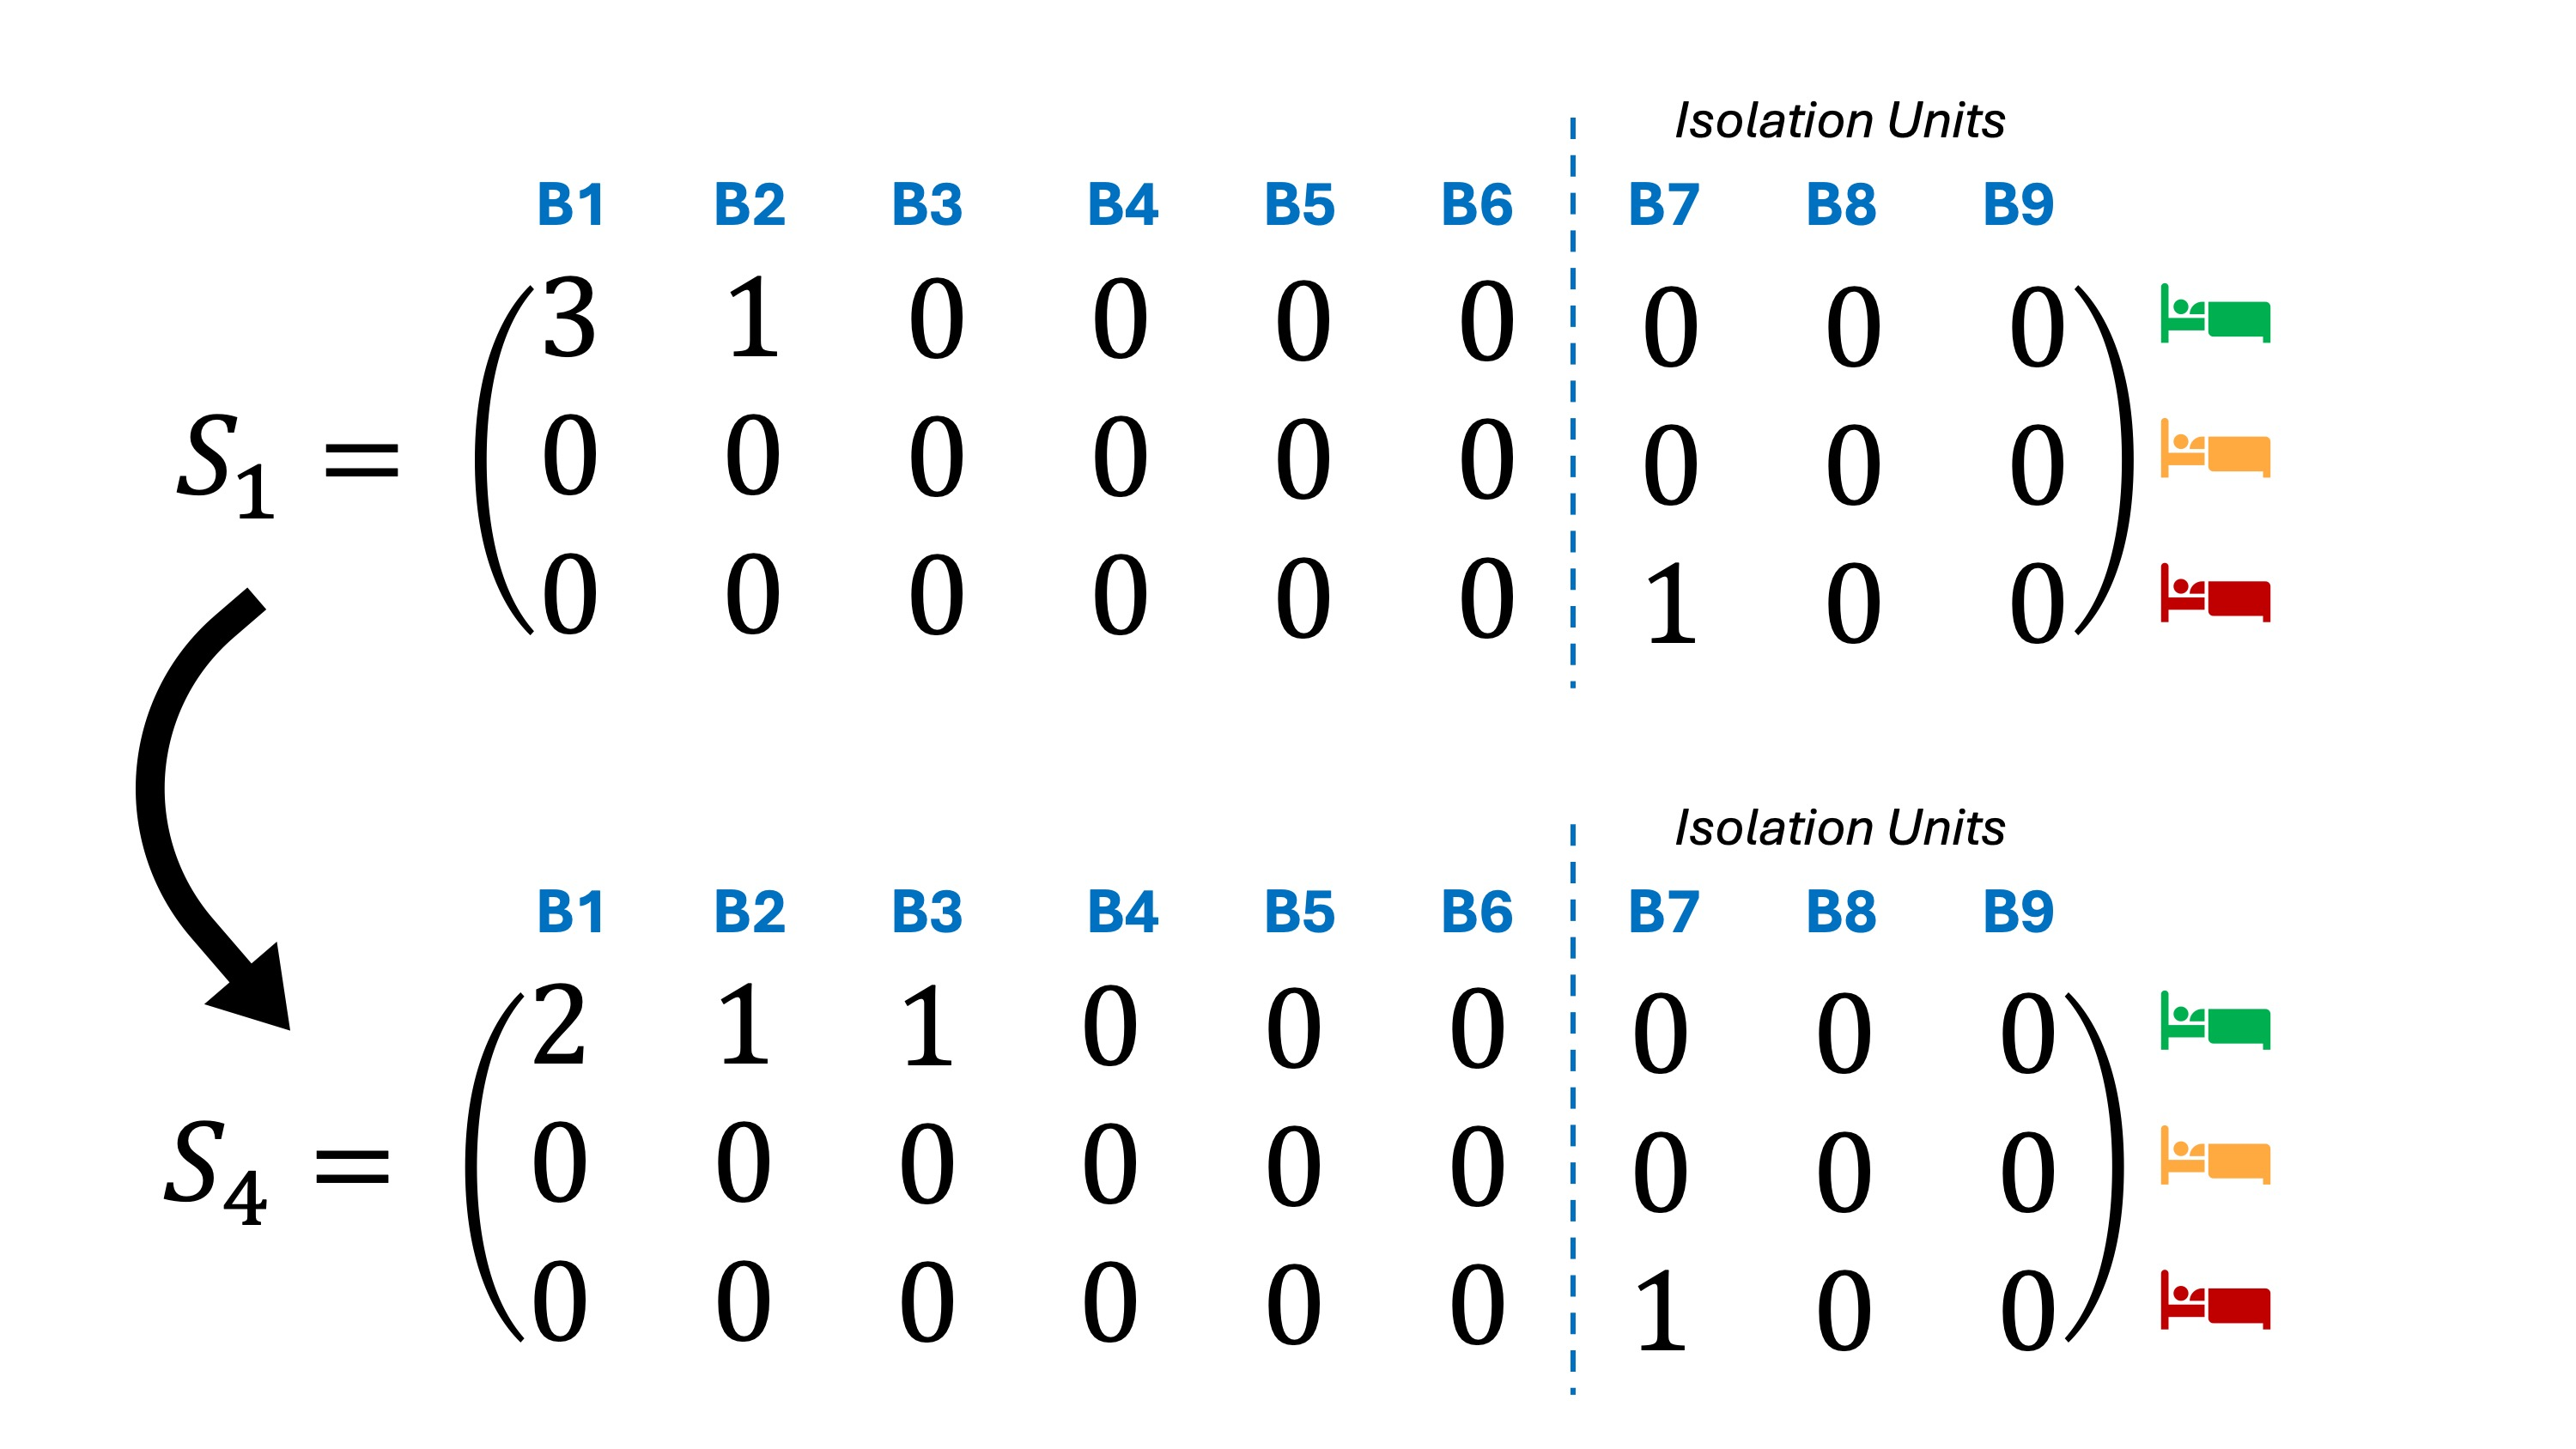

We can identify if a transition is an arrival, departure, or a move by considering the difference between two states:
+ if the sum of the differences is -1, then an arrival has occured.
+ if the sum of the differences is +1, then a departure has occurred.
+ if the sum of the differences is 0, then a bed move has occurred. We can count the number of bed moves the happened by summing the absolute differences between the states.

In [11]:
S1 = np.matrix(
    (
        (3, 1, 0, 0, 0, 0, 0, 0, 0),
        (0, 0, 0, 0, 0, 0, 0, 0, 0),
        (0, 0, 0, 0, 0, 0, 0, 0, 0)
    )
)

S2 = np.matrix(
    (
        (3, 2, 0, 0, 0, 0, 0, 0, 0),
        (0, 0, 0, 0, 0, 0, 0, 0, 0),
        (0, 0, 0, 0, 0, 0, 0, 0, 0)
    )
)

S3 = np.matrix(
    (
        (2, 1, 0, 0, 0, 0, 0, 0, 0),
        (0, 0, 0, 0, 0, 0, 0, 0, 0),
        (0, 0, 0, 0, 0, 0, 0, 0, 0)
    )
)

S4 = np.matrix(
    (
        (2, 1, 1, 0, 0, 0, 0, 0, 0),
        (0, 0, 0, 0, 0, 0, 0, 0, 0),
        (0, 0, 0, 0, 0, 0, 0, 0, 0)
    )
)

In [12]:
## An arrival
(S1 - S2).sum()

np.int64(-1)

In [13]:
## A departure
(S1 - S3).sum()

np.int64(1)

In [14]:
## A bed move
(S1 - S4).sum()

np.int64(0)

In [15]:
np.absolute(S1 - S4).sum()

np.int64(2)

Bed moves are considered bad for patient outcomes, and so are discouraged using a penalty. The bed move penalty depends on how far the patient moved in a ward.
+ Moving to an adjacent block incurs a penalty of $\beta_1$,
+ Moving to a non-adjacent block incurs a penalty of $\beta_2$ (where $\beta_1 < \beta_2)$
This is because moving to an adjacent block may not in actuality constitute a physical bed move, just an extension of a nurse's duties.

Isolation wards are no considered adjacent to any other block. The network of adjacent blocks is given below:

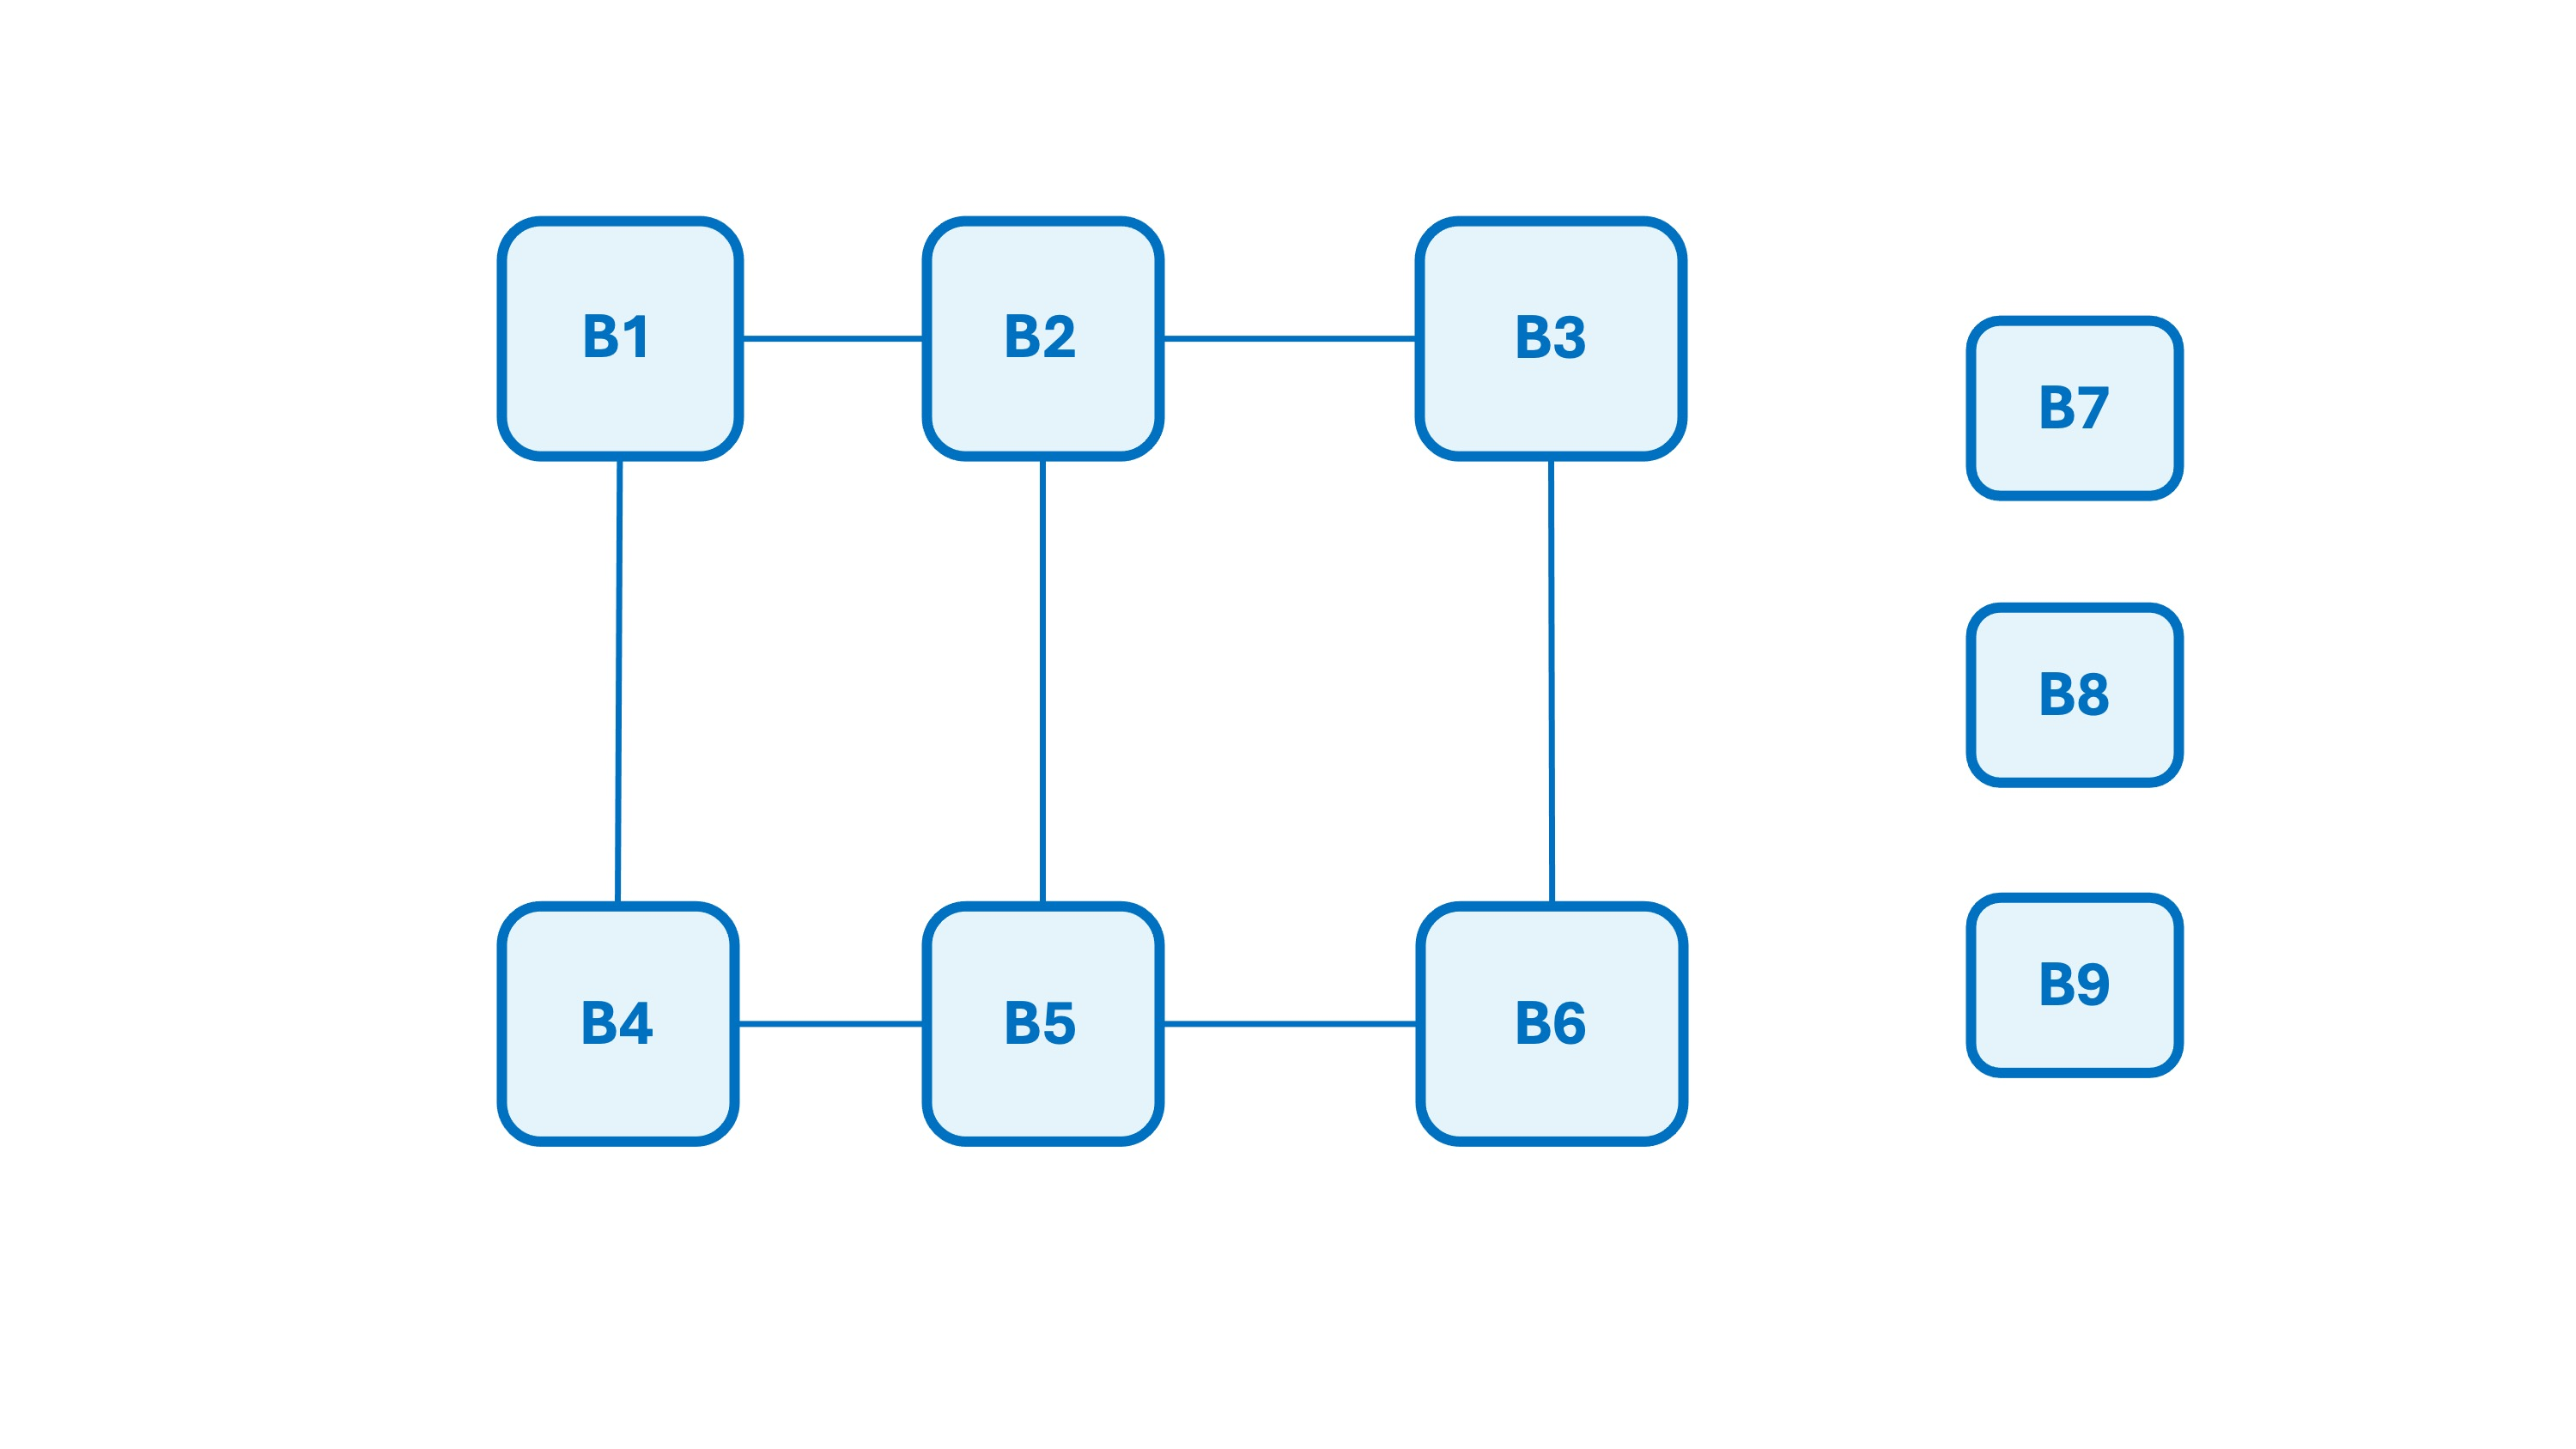

In [23]:
def get_move_penalty(from_block, to_block, b1, b2):
    M = [
        [0, b1, b2, b1, b2, b2, b2, b2, b2],
        [b1, 0, b1, b2, b1, b2, b2, b2, b2],
        [b2, b1, 0, b2, b2, b1, b2, b2, b2],
        [b1, b2, b2, 0, b1, b2, b2, b2, b2],
        [b2, b1, b2, b1, 0, b1, b2, b2, b2],
        [b2, b2, b1, b2, b1, 0, b2, b2, b2],
        [b2, b2, b2, b2, b2, b2, 0, b2, b2],
        [b2, b2, b2, b2, b2, b2, b2, 0, b2],
        [b2, b2, b2, b2, b2, b2, b2, b2, 0]
    ]
    return M[from_block - 1][to_block - 1]

In [24]:
get_move_penalty(1, 2, 10, 20)

10

In [25]:
get_move_penalty(1, 1, 10, 20)

0

In [26]:
get_move_penalty(1, 3, 10, 20)

20

### Action sets

In [27]:
def move_patient(state, patient_type, from_block, to_block):
    """
    Returns the state that results form moving a patient.

    Arguments:
      - `state` a 9x3 matrix of integers {0, 1, 2, 3} representing
         the state of the ward.
      - `patient_type`: the type of the patient being moved, either
         2: 'red', 1: 'amber', or 0: 'green'
      - `from_block`: the block the patient was moved from
      - `to_block`: the block the patient is moved to
    """
    new_state = state.copy()
    new_state[patient_type, from_block] -= 1
    new_state[patient_type, to_block] += 1
    return new_state

In [77]:
S = np.array(
    (
        (0, 2, 0, 2, 0, 0, 0, 0, 0),
        (0, 0, 1, 1, 0, 0, 0, 0, 0),
        (0, 0, 0, 0, 0, 1, 1, 1, 0)
    )
)
expected_newS = np.matrix(
    (
        (0, 1, 1, 2, 0, 0, 0, 0, 0),
        (0, 0, 1, 1, 0, 0, 0, 0, 0),
        (0, 0, 0, 0, 0, 1, 1, 1, 0)
    )
)
newS = move_patient(S, 0, 2, 3)

In [78]:
newS

array([[ 0,  2, -1,  3,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  1,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  1,  1,  0]])

In [79]:
S[:,3].sum()

np.int64(3)

In [86]:
np.where(S[2,:] > 0)[0]

array([5, 6, 7])

In [58]:
S

matrix([[0, 2, 0, 2, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 0]])

In [64]:
def get_available_insert_moves(state):
    """
    Lists all available places where a patient can be inserted.

    Arguments:
      - `state` a 9x3 matrix of integers {0, 1, 2, 3} representing
         the state of the ward.

    Returns: a list of blocks that the patient can be inserted.    
    """
    available_moves = []
    for i, capacity in enumerate(max_capacities):
        free_beds = capacity - state[:,i].sum()
        if free_beds > 0:
            available_moves.append(i + 1)
    return available_moves


def get_available_moves(state):
    """
    Lists all available bed moves possible.

    Arguments:
      - `state` a 9x3 matrix of integers {0, 1, 2, 3} representing
         the state of the ward.

    Returns: a list of possible moves, that is tuples (a, b, c),
        where a is the patient type, b is where they move from,
        and c is where they can move to.
    """
    available_moves = []
    available_interts = get_available_insert_moves(state)
    for patient_type in range(3):
        from_blocks = np.where(state[patient_type,:] > 0)[1]
        for from_block in from_blocks:
            for to_block in available_interts:
                if from_block + 1 != to_block:
                    available_moves.append((patient_type, from_block + 1, to_block))
    return available_moves

In [65]:
S = np.matrix(
        (
            (0, 2, 0, 2, 0, 0, 0, 0, 0),
            (1, 0, 1, 0, 0, 0, 0, 0, 0),
            (0, 0, 0, 1, 0, 1, 1, 1, 0)
        )
    )

In [66]:
get_available_moves(S)

[(0, np.int64(2), 1),
 (0, np.int64(2), 3),
 (0, np.int64(2), 5),
 (0, np.int64(2), 6),
 (0, np.int64(2), 9),
 (0, np.int64(4), 1),
 (0, np.int64(4), 3),
 (0, np.int64(4), 5),
 (0, np.int64(4), 6),
 (0, np.int64(4), 9),
 (1, np.int64(1), 3),
 (1, np.int64(1), 5),
 (1, np.int64(1), 6),
 (1, np.int64(1), 9),
 (1, np.int64(3), 1),
 (1, np.int64(3), 5),
 (1, np.int64(3), 6),
 (1, np.int64(3), 9),
 (2, np.int64(4), 1),
 (2, np.int64(4), 3),
 (2, np.int64(4), 5),
 (2, np.int64(4), 6),
 (2, np.int64(4), 9),
 (2, np.int64(6), 1),
 (2, np.int64(6), 3),
 (2, np.int64(6), 5),
 (2, np.int64(6), 9),
 (2, np.int64(7), 1),
 (2, np.int64(7), 3),
 (2, np.int64(7), 5),
 (2, np.int64(7), 6),
 (2, np.int64(7), 9),
 (2, np.int64(8), 1),
 (2, np.int64(8), 3),
 (2, np.int64(8), 5),
 (2, np.int64(8), 6),
 (2, np.int64(8), 9)]

In [72]:
S = np.array(
        (
            (0, 0, 0, 0, 0, 0, 0, 0, 0),
            (0, 0, 0, 0, 0, 0, 0, 0, 0),
            (0, 0, 0, 0, 0, 0, 0, 0, 0)
        )
    )

In [70]:
get_available_moves(S)

[]

In [71]:
S

matrix([[0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [87]:
A = {'a': 67, 'b': 3, 'c': 100}

In [94]:
max(A, key=A.get)

'c'